#Label Contradiction Prediction
- Authors: Taima Nasser & Fadi Bassous

##Project Overview

##Utility Functions

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def classification_metrics(y_true, y_pred, label="",
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
    # Get the classification report (string version)
    report = classification_report(y_true, y_pred)

    # Print header and report
    header = "-"*76
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    # Create confusion matrix plots side by side
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # Raw counts confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                                            normalize=None, cmap='gist_gray',
                                            colorbar=colorbar, ax=axes[0])
    axes[0].set_title("Raw Counts")

    # Normalized confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                                            normalize=normalize, cmap=cmap,
                                            colorbar=colorbar, ax=axes[1])
    axes[1].set_title("Normalized Confusion Matrix")

    # Layout
    fig.tight_layout()
    plt.show()

    # Return dictionary of classification_report (optional)
    if output_dict:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true',
                            output_dict=False,
                            cmap_train='Blues', cmap_test='Reds',
                            colorbar=False):
    # Get predictions for training data
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(y_train, y_train_pred,
                                           output_dict=True, figsize=figsize,
                                           colorbar=colorbar, cmap=cmap_train,
                                           label='Training Data')

    print()  # Line break for readability

    # Get predictions for test data
    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(y_test, y_test_pred,
                                          output_dict=True, figsize=figsize,
                                          colorbar=colorbar, cmap=cmap_test,
                                          label='Test Data')

    # Return results as dictionary if requested
    if output_dict:
        results_dict = {'train': results_train,
                        'test': results_test}
        return results_dict

def plot_history(history, figsize=(6,12), marker='o'):
    metrics = [m for m in history.history if not m.startswith('val_')]

    fig, axes = plt.subplots(nrows=len(metrics), figsize=figsize)

    for i, metric_name in enumerate(metrics):
        ax = axes[i]
        epochs = history.epoch

        ax.plot(epochs, history.history[metric_name],
                label=metric_name, marker=marker)

        val_metric = f"val_{metric_name}"
        if val_metric in history.history:
            ax.plot(epochs, history.history[val_metric],
                    label=val_metric, marker=marker)

        ax.set_title(metric_name)
        ax.legend()

    fig.tight_layout()
    return fig, axes

def build_model(hp):
    model = Sequential()

    # First hidden layer (fixed)
    model.add(Dense(
        units=hp.Int("units_1", min_value=32, max_value=128, step=32),
        activation="relu",
        input_dim=input_shape
    ))

    model.add(Dropout(
        hp.Float("dropout_1", min_value=0.1, max_value=0.5, step=0.1)
    ))

    # Second hidden layer (tuned)
    model.add(Dense(
        units=hp.Int("units_2", min_value=16, max_value=64, step=16),
        activation="relu"
    ))

    model.add(Dropout(
        hp.Float("dropout_2", min_value=0.1, max_value=0.5, step=0.1)
    ))

    # Output layer (binary)
    model.add(Dense(1, activation="sigmoid"))

    # Tuned learning rate
    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4, 5e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision")
        ]
    )

    return model



##Imports & Loading

In [ ]:
#downloadin keras tuner
!pip install -q -U keras-tuner

In [ ]:
#importing packages we could need
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve,classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
pd.set_option('display.max_columns', 100)

In [ ]:
#reading from file path
fpath="new_dataset.csv"
df=pd.read_csv(fpath)

###Checking the general information of the dataset:

In [ ]:
df.head(15)

,Description,Country,Weather,Time of Day,Season,Activity,Mood/Emotion,student_id
0,A clear image of the Dome of the Rock in Jerus...,Palestine,Sunny,Afternoon,Summer,Sightseeing,Nostalgia,1161937
1,a clear image of the Ibrahimi Mosque (Cave of ...,Palestine,Sunny,Morning,Spring,Sightseeing,Curiosity,1161937
2,A clear image of the ancient ruins in Sebastia...,Palestine,Sunny,Afternoon,Summer,Exploring,Adventure,1161937
3,A clear image of Mar Saba Monastery in Bethleh...,Palestine,Sunny,Afternoon,Summer,Sightseeing,Awe,1161937
4,A clear aerial view of Tell es-Sultan in Jeric...,Palestine,Sunny,Morning,Spring,Exploring,Curiosity,1161937
5,A night view of the Eiffel Tower illuminated i...,France,Not Clear,Afternoon,Not Clear,Sightseeing,Romance,1161937
6,A bright and clear view of the Great Wall of C...,China,Sunny,Morning,Summer,Hiking,Adventure,1161937
7,"A beautiful sunset view in Santorini, Greece, ...",Greece,Clear,Evening,Summer,Relaxing,Happiness,1161937
8,A stunning nighttime panorama of New York City...,USA,Clear,Evening,Winter,Sightseeing,Excitement,1161937
9,A bright and peaceful beach view in the Maldiv...,Maldives,Sunny,Afternoon,Summer,Relaxing,Happiness,1161937


This displays the first 15 rows of the dataset to get a quick look at the structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028 entries, 0 to 1027
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Description   1028 non-null   object
 1   Country       1028 non-null   object
 2   Weather       1028 non-null   object
 3   Time of Day   1028 non-null   object
 4   Season        1028 non-null   object
 5   Activity      1007 non-null   object
 6   Mood/Emotion  1027 non-null   object
 7   student_id    1028 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 64.4+ KB


This provides a summary of the dataset including column types and non-null counts to help check for missing data

* We can see that there are:
  *  1028 rows
  * 8 features
  * **Activity** has missing values

##Data Cleaning

In [ ]:
#dropping the CustomerID column to reduce noise in model
df = df.drop(columns=['Mood/Emotion'])

In [ ]:
df["Activity"] = df["Activity"].fillna("no activity")

###Common Normalization Utilities

In [ ]:
UNKNOWN_TOKENS = {"not clear", "no clear", "unknown", "nan", "none", "", "null"}

def norm(s: str) -> str:
    return str(s).strip().lower()

def is_unknown(s: str) -> bool:
    return norm(s) in UNKNOWN_TOKENS

Provide reusable helpers for string normalization and missing/unknown value detection.

###Season Normalization

In [ ]:
df["Season"] = (
    df["Season"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
)
def fix_season(value):
    # missing / garbage
    if value in {"not clear", "clear", "nan", "none", "null", ""}:
        return "Not Clear"

    # synonyms
    if value in {"autumn"}:
        return "Fall"

    # valid seasons
    if value == "summer":
        return "Summer"
    if value == "spring":
        return "Spring"
    if value == "winter":
        return "Winter"
    if value == "fall":
        return "Fall"

    # fallback (anything unexpected)
    return "Not Clear"
df["Season"] = df["Season"].apply(fix_season)


In [ ]:
#view values in features
df["Season"].value_counts()

,count
Season,
Summer,393
Spring,205
Winter,161
Fall,149
Not Clear,120


Normalize season labels into a consistent, limited vocabulary.

###Time of Day Normalization

In [ ]:
df["Time of Day"] = (
    df["Time of Day"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(",", "", regex=False)
    .str.lower()
)
def fix_time_of_day(value):
    # missing / unclear
    if value in {"not clear", "nan", "none", "null", ""}:
        return "Not Clear"

    # morning variants
    if value in {"morning", "sunrise", "morninglt"}:
        return "Morning"

    # afternoon variants
    if value in {"afternoon", "daytime", "noon"}:
        return "Afternoon"

    # evening variants
    if value in {"evening", "sunset", "evning"}:
        return "Evening"

    # night
    if value == "night":
        return "Night"

    # fallback
    return "Not Clear"
df["Time of Day"] = df["Time of Day"].apply(fix_time_of_day)


Standardize time-of-day values while preserving meaningful distinctions such as sunrise/sunset.

###Weather Normalization

In [ ]:
df["Weather"] = (
    df["Weather"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
)
def fix_weather(value):
    # -----------------------
    # missing / unclear
    # -----------------------
    if value in {"not clear", "no clear", "nan", "none", "null", ""}:
        return "Not Clear"

    # -----------------------
    # snowy conditions
    # -----------------------
    if "snow" in value:
        return "Snowy"

    # -----------------------
    # rainy conditions
    # -----------------------
    if value == "raniy" or "rain" in value:
        return "Rainy"

    # -----------------------
    # cloudy conditions
    # -----------------------
    if "cloud" in value:
        return "Cloudy"

    # -----------------------
    # sunny / clear conditions
    # -----------------------
    if "sun" in value:
        return "Sunny"

    if "clear" in value:
        # clear night sky, cold/clear, etc.
        return "Sunny"

    # -----------------------
    # cold / windy (ambiguous)
    # -----------------------
    if "cold" in value or "wind" in value:
        return "Not Clear"

    # -----------------------
    # fallback
    # -----------------------
    return "Not Clear"
df["Weather"] = df["Weather"].apply(fix_weather)


Collapse diverse weather descriptions into interpretable, high-level categories suitable for rule-based reasoning.

###Activity Bucketing via Keyword Matching

In [ ]:
#view values in features
df["Activity"].value_counts()

,count
Activity,
Sightseeing,471
Relaxing,135
Hiking,94
no activity,21
Exploring,20
...,...
Exploring,1
religious,1
Cultural tour,1


In [ ]:
BUCKET_KEYWORDS = {

    # General tourism / passive visiting
    "sightseeing": {
        "sightseeing", "touring", "visiting", "visiting landmarks",
        "tourism", "traveling",
        "city sightseeing", "heritage sightseeing", "historical sightseeing",
        "scenic viewpoint sightseeing", "siteseeking","exploring"

    },

    # Hiking & strenuous outdoor movement
    "hiking": {
        "hiking", "mountain hiking", "hiking in the mountains",
        "hiking and exploring nature", "nature walk",
        "winter walking", "trail"
    },

    # Walking / strolling (lighter movement)
    "walking": {
        "walking", "city walk", "city walking", "walking tour",
        "strolling", "strolling the plaza",
        "city stroll", "walking around the city",
        "walking / city exploring", "walking / photography"
    },

    # Nature appreciation / observation
    "nature": {
        "nature watching", "viewing nature",
        "mountain viewing", "aurora watching",
        "stargazing", "wildlife watching",
        "exploring nature", "nature exploration"
    },

    # Water-related activities
    "water": {
        "swimming", "boating", "boat ride", "boat tour",
        "rowing", "diving", "scuba diving",
        "snorkeling", "snorkelling", "sailing",
        "canoeing", "surfing", "beachgoing",
        "canal touring"
    },

    # Winter / snow activities
    "winter_sport": {
        "skiing", "ice skating",
        "snow activities", "skiing / winter activities"
    },

    # Urban exploration / city life
    "urban": {
        "city exploring", "city exploration",
        "urban exploration", "urban exploring",
        "urban life", "downtown", "urban"
    },

    # Cultural / heritage
    "cultural": {
        "cultural visit", "cultural exploration",
        "cultural tour", "cultural experience",
        "heritage", "history tour",
        "historical touring", "exploring ruins"
    },

    # Religious / spiritual
    "religious": {
        "praying", "prayer", "worship",
        "worshipping", "religious pilgrimage",
        "pilgrimage", "spiritual visit",
        "religious/spiritual visit",
        "praying / worshiping"
    },

    # Relaxation / leisure
    "relaxing": {
        "relaxing", "park relaxation",
        "relaxing in nature", "resort stay",
        "romance", "meditation",
        "breakfast in front of",
        "relaxing / sightseeing","vacation", "vacationing",
        "relaxing / nature viewing"
    },

    # Adventure / thrill
    "adventure": {
        "skydiving", "skydriving", "bungee jumping",
        "camel riding", "safari",
        "hot air balloon", "hot-air balloon",
        "ballooning", "cliff jumping",
        "cycling", "biking"
    },

    # Sports (watching, not playing)
    "sports_event": {
        "football", "watching a football match",
        "football fan", "stadium tour",
        "attending a sports venue",
        "spectating"
    },

    # Entertainment / events
    "entertainment": {
        "festival participation", "celebration",
        "entertainment", "gaming",
        "music", "party"
    },
    "camping": {
        "camping"
    },
    "photography": {
        "photography", "photo", "photos",
        "taking pictures"
    }

}
def activity_buckets(activity: str) -> set:
    a = norm(activity)
    if a in UNKNOWN_TOKENS or a in {"no activity", "none"}:
        return {"unknown"}

    buckets = set()
    for b, kws in BUCKET_KEYWORDS.items():
        for kw in kws:
            if kw in a:
                buckets.add(b)
                break

    return buckets if buckets else {"other"}
def activity_canon(activity: str) -> str:
    buckets = activity_buckets(activity)  # returns a set

    if "unknown" in buckets:
        return "unknown"
    if "other" in buckets:
        return "other"

    # choose the first bucket based on priority
    for b in buckets:
            return b

    return "other"
df["Activity"] = df["Activity"].apply(activity_canon)



In [ ]:
# =========================================
# Activity Bucket Coverage Diagnostics
# =========================================

from collections import Counter
from itertools import combinations

# 1) Assign activity buckets temporarily
df["activity_buckets_tmp"] = df["Activity"].apply(activity_buckets)

# 2) Bucket counts (multi-label aware)
bucket_counts = (
    df["activity_buckets_tmp"]
    .explode()
    .value_counts()
)

print("\n=== Bucket Counts ===")
print(bucket_counts)

# 3) Bucket percentages
bucket_percent = (bucket_counts / len(df) * 100).round(2)

print("\n=== Bucket Percentages (%) ===")
print(bucket_percent)

# 4) Number of buckets per row (overlap analysis)
df["num_buckets"] = df["activity_buckets_tmp"].apply(len)

print("\n=== Number of Buckets per Row ===")
print(df["num_buckets"].value_counts().sort_index())

# 5) Leakage check: 'other' and 'unknown'
print("\n=== 'other' / 'unknown' Leakage ===")
for label in ["other", "unknown"]:
    if label in bucket_counts:
        print(f"{label}: {bucket_counts[label]} rows ({bucket_percent[label]}%)")
    else:
        print(f"{label}: 0 rows (0%)")

# 6) Inspect top activities that fell into 'other'
print("\n=== Top Activities in 'other' ===")
other_activities = df[df["activity_buckets_tmp"] == {"other"}]["Activity"]
print(other_activities.value_counts().head(20))

# 7) Most common bucket overlaps (top 10)
pair_counts = Counter()

for buckets in df["activity_buckets_tmp"]:
    for a, b in combinations(sorted(buckets), 2):
        pair_counts[(a, b)] += 1

print("\n=== Top Bucket Overlaps ===")
for pair, count in pair_counts.most_common(10):
    print(f"{pair}: {count}")

# 8) Cleanup temporary columns
df.drop(columns=["activity_buckets_tmp", "num_buckets"], inplace=True)

print("\nDiagnostics complete. Temporary columns removed.")



=== Bucket Counts ===
activity_buckets_tmp
sightseeing      526
relaxing         156
other            140
hiking           106
walking           34
unknown           28
urban             22
photography       10
entertainment      3
camping            3
Name: count, dtype: int64

=== Bucket Percentages (%) ===
activity_buckets_tmp
sightseeing      51.17
relaxing         15.18
other            13.62
hiking           10.31
walking           3.31
unknown           2.72
urban             2.14
photography       0.97
entertainment     0.29
camping           0.29
Name: count, dtype: float64

=== Number of Buckets per Row ===
num_buckets
1    1028
Name: count, dtype: int64

=== 'other' / 'unknown' Leakage ===
other: 140 rows (13.62%)
unknown: 28 rows (2.72%)

=== Top Activities in 'other' ===
Activity
religious       30
water           25
other           21
adventure       19
cultural        15
nature          13
winter_sport     9
sports_event     8
Name: count, dtype: int64

=== Top Bucket O

In [ ]:
sample_df = df.sample(5)

sample_df[["Activity"]].assign(
    buckets = sample_df["Activity"].apply(activity_buckets)
)


,Activity,buckets
427,sightseeing,{sightseeing}
841,sightseeing,{sightseeing}
591,sightseeing,{sightseeing}
537,winter_sport,{other}
140,sightseeing,{sightseeing}


In [ ]:
print(df["Activity"].value_counts().head(30))
print("unknown:", (df["Activity"] == "unknown").mean().round(4))
print("other:", (df["Activity"] == "other").mean().round(4))


Activity
sightseeing      526
relaxing         156
hiking           106
walking           34
religious         30
unknown           28
water             25
urban             22
other             21
adventure         19
cultural          15
nature            13
photography       10
winter_sport       9
sports_event       8
entertainment      3
camping            3
Name: count, dtype: int64
unknown: 0.0272
other: 0.0204


In [ ]:
#view values in features
df["Weather"].value_counts()

,count
Weather,
Sunny,608
Cloudy,211
Not Clear,102
Snowy,87
Rainy,20


Reduce highly variable free-text activity descriptions into a small, semantically meaningful set of activity categories.

###Rule-Based Contradiction Detection Logic

In [ ]:
def is_contradictory(row):
    """
    Calibrated contradiction detection logic.
    Designed for weak supervision with student-generated travel data.
    """

    weather = row["Weather"]          # Sunny, Cloudy, Rainy, Snowy, Not Clear
    season  = row["Season"]           # Summer, Spring, Fall, Winter, Not Clear
    tod     = row["Time of Day"]       # Morning, Afternoon, Evening, Night, Not Clear
    act_raw = norm(row["Activity"])
    ab      = activity_buckets(act_raw)

    hard = False
    soft = 0.0

    # =================================================
    # HARD CONTRADICTIONS (physical / near-impossible)
    # =================================================

    if weather == "Snowy" and season in {"Summer", "Spring"}:
        hard = True

    if weather == "Sunny" and tod == "Night":
        hard = True

    if "winter_sport" in ab and season in {"Summer", "Spring"}:
        hard = True

    if "water" in ab and weather == "Snowy":
        hard = True

    if ("snow" in act_raw or "winter" in act_raw) and season in {"Summer", "Spring"}:
        hard = True

    if tod == "Night" and "hiking" in ab:
        hard = True
    if weather == "Rainy" and tod == "Night" and "sightseeing" in ab:
        hard = True
    # =================================================
    # SOFT CONTRADICTIONS (human inconsistency)
    # =================================================

    # ---- Time vs Activity ----
    if tod == "Night" and "water" in ab:
        soft += 0.7

    if tod == "Morning" and "sports_event" in ab:
        soft += 0.6

    if tod == "Night" and "sightseeing" in ab:
        soft += 0.8

    # ---- Weather vs Activity ----
    if weather == "Rainy" and "sightseeing" in ab:
        soft += 0.6

    if weather == "Rainy" and "hiking" in ab:
        soft += 0.8

    if weather == "Snowy" and "sightseeing" in ab:
        soft += 0.8

    if weather == "Snowy" and "hiking" in ab:
        soft += 0.7

    # ---- Season vs Activity ----
    if season == "Winter" and "water" in ab:
        soft += 0.7

    if season == "Winter" and "sightseeing" in ab:
        soft += 0.4

    if season == "Summer" and "winter_sport" in ab:
        soft += 0.8

    # ---- Cross-intent conflicts ----
    if "adventure" in ab and "relaxing" in ab:
        soft += 0.9

    if "sports_event" in ab and "relaxing" in ab:
        soft += 0.8

    if "cultural" in ab and "adventure" in ab:
        soft += 0.5

    # ---- Data quality signals ----
    unknown_count = sum([
        weather == "Not Clear",
        season  == "Not Clear",
        tod     == "Not Clear",
        "unknown" in ab
    ])

    if unknown_count >= 1:
        soft += 0.6
    if unknown_count >= 2:
        soft += 0.8
    if unknown_count >= 3:
        soft += 1

    if "other" in ab:
        soft += 0.4

    # =================================================
    # FINAL DECISION
    # =================================================

    if hard:
        return True

    # Lowered threshold to reflect weak supervision
    return soft >= 0.8


Define interpretable rule-based logic to determine whether an entry is internally contradictory. Capture strong physical or semantic inconsistencies that almost certainly indicate contradictions.Handle context-dependent inconsistencies and data-quality uncertainty in a controlled manner.

###Dataset Labeling Pipeline

In [ ]:
def add_consistency_label(df):
    df = df.copy()

    df["Consistency_Label"] = df.apply(
        lambda r: "Contradictory" if is_contradictory(r) else "Consistent",
        axis=1
    )

    return df
df = add_consistency_label(df)

In [ ]:
print(df["Consistency_Label"].value_counts())

Consistency_Label
Consistent       891
Contradictory    137
Name: count, dtype: int64


Apply the contradiction detection logic to the full dataset and generate the final target label.

In [ ]:
df.head(60)

,Description,Country,Weather,Time of Day,Season,Activity,student_id,Consistency_Label
0,A clear image of the Dome of the Rock in Jerus...,Palestine,Sunny,Afternoon,Summer,sightseeing,1161937,Consistent
1,a clear image of the Ibrahimi Mosque (Cave of ...,Palestine,Sunny,Morning,Spring,sightseeing,1161937,Consistent
2,A clear image of the ancient ruins in Sebastia...,Palestine,Sunny,Afternoon,Summer,sightseeing,1161937,Consistent
3,A clear image of Mar Saba Monastery in Bethleh...,Palestine,Sunny,Afternoon,Summer,sightseeing,1161937,Consistent
4,A clear aerial view of Tell es-Sultan in Jeric...,Palestine,Sunny,Morning,Spring,sightseeing,1161937,Consistent
5,A night view of the Eiffel Tower illuminated i...,France,Not Clear,Afternoon,Not Clear,sightseeing,1161937,Contradictory
6,A bright and clear view of the Great Wall of C...,China,Sunny,Morning,Summer,hiking,1161937,Consistent
7,"A beautiful sunset view in Santorini, Greece, ...",Greece,Sunny,Evening,Summer,relaxing,1161937,Consistent
8,A stunning nighttime panorama of New York City...,USA,Sunny,Evening,Winter,sightseeing,1161937,Consistent
9,A bright and peaceful beach view in the Maldiv...,Maldives,Sunny,Afternoon,Summer,relaxing,1161937,Consistent


## Missing values

In [ ]:
df.isnull().sum()


,0
Description,0
Country,0
Weather,0
Time of Day,0
Season,0
Activity,0
student_id,0
Consistency_Label,0


no missing values

In [ ]:
df.to_csv("final_dataset.csv")


##EDA

###Target Variable Analysis

In [ ]:
df["Consistency_Label"].value_counts()


,count
Consistency_Label,
Consistent,891
Contradictory,137


In [ ]:
df["Consistency_Label"].value_counts(normalize=True).round(3)*100

,proportion
Consistency_Label,
Consistent,86.7
Contradictory,13.3


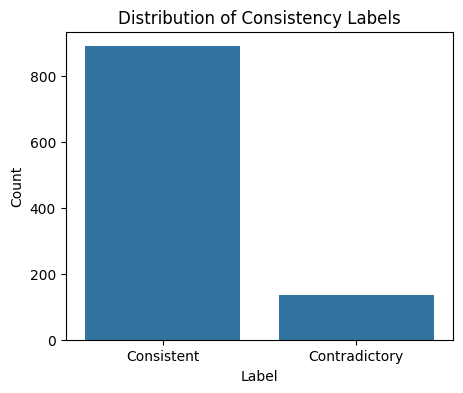

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Consistency_Label")
plt.title("Distribution of Consistency Labels")
plt.ylabel("Count")
plt.xlabel("Label")
plt.show()

Most entries are labeled Consistent, while a smaller portion is labeled Contradictory.
This shows a moderate class imbalance, which is expected in real-world, weakly supervised data.

###Univairate Feature Distributions

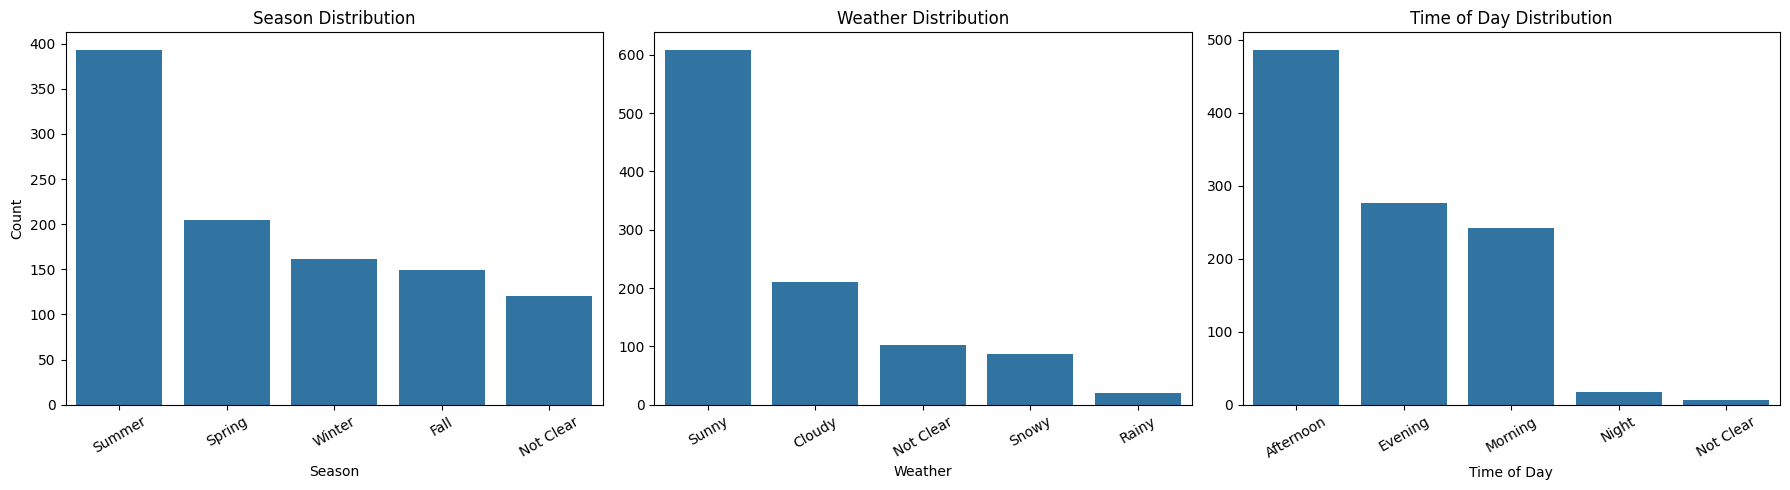

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# Season distribution
sns.countplot(
    data=df,
    x="Season",
    order=df["Season"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Season Distribution")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Weather distribution
sns.countplot(
    data=df,
    x="Weather",
    order=df["Weather"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Weather Distribution")
axes[1].set_xlabel("Weather")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=30)

# Time of Day distribution
sns.countplot(
    data=df,
    x="Time of Day",
    order=df["Time of Day"].value_counts().index,
    ax=axes[2]
)
axes[2].set_title("Time of Day Distribution")
axes[2].set_xlabel("Time of Day")
axes[2].set_ylabel("")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


The dataset is dominated by Summer, Sunny weather, and Afternoon time of day, indicating a natural bias toward favorable travel conditions. Less frequent categories such as Snowy weather and Night time reflect more extreme or ambiguous contexts.

In [ ]:
from collections import Counter

bucket_counts = Counter()

for buckets in df["Activity"].apply(activity_buckets):
    for b in buckets:
        bucket_counts[b] += 1

bucket_df = (
    pd.DataFrame.from_dict(bucket_counts, orient="index", columns=["Count"])
    .sort_values("Count", ascending=False)
)

bucket_df


,Count
sightseeing,526
relaxing,156
other,140
hiking,106
walking,34
unknown,28
urban,22
photography,10
entertainment,3
camping,3


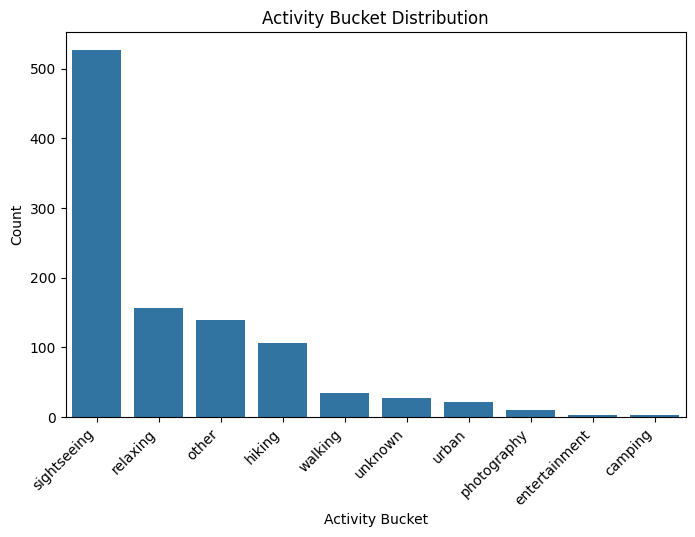

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=bucket_df.index,
    y=bucket_df["Count"]
)
plt.title("Activity Bucket Distribution")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.xlabel("Activity Bucket")
plt.show()


Most activities fall under Sightseeing, followed by Relaxing and Hiking, indicating that general tourism and leisure dominate the dataset.
Smaller buckets such as Winter Sport, Sports Event, and Camping appear less frequently, which is expected for student travel preferences.

In [ ]:
df["student_id"].value_counts().describe()


,count
count,103.000000
mean,9.980583
std,0.138662
min,9.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


Each student contributed almost exactly 10 entries, with very little variation.
This indicates a well-balanced dataset where no single student dominates the data.

In [ ]:
student_contradiction_rate = (
    df.assign(
        is_contradictory = df["Consistency_Label"] == "Contradictory"
    )
    .groupby("student_id")["is_contradictory"]
    .mean()
)

student_contradiction_rate.describe()


,is_contradictory
count,103.000000
mean,0.133225
std,0.119280
min,0.000000
25%,0.000000
50%,0.100000
75%,0.200000
max,0.500000


On average, students have a contradiction rate of about 12%, which aligns well with the overall dataset distribution.
Most students have low contradiction rates, while a small number exhibit higher rates, reflecting natural variation in annotation quality.

###Feature vs Target Analysis

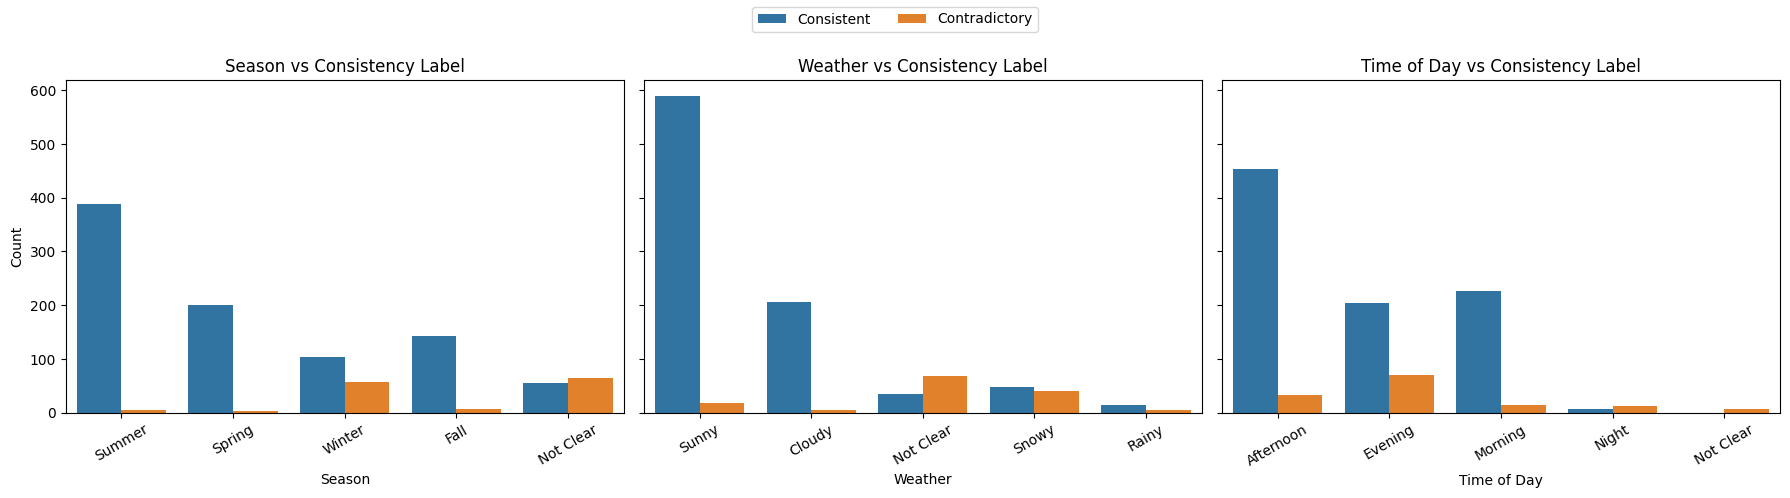

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# --- Season vs Label ---
sns.countplot(
    data=df,
    x="Season",
    hue="Consistency_Label",
    order=df["Season"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Season vs Consistency Label")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

# --- Weather vs Label ---
sns.countplot(
    data=df,
    x="Weather",
    hue="Consistency_Label",
    order=df["Weather"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Weather vs Consistency Label")
axes[1].set_xlabel("Weather")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=30)

# --- Time of Day vs Label ---
sns.countplot(
    data=df,
    x="Time of Day",
    hue="Consistency_Label",
    order=df["Time of Day"].value_counts().index,
    ax=axes[2]
)
axes[2].set_title("Time of Day vs Consistency Label")
axes[2].set_xlabel("Time of Day")
axes[2].set_ylabel("")
axes[2].tick_params(axis='x', rotation=30)

# --- Shared legend ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

for ax in axes:
    ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


**Season vs Consistency Label**

Contradictions occur more frequently in **Winter and Not Clear** seasons compared to Summer and Spring.
This suggests that extreme or unclear seasonal conditions are more likely to lead to inconsistent entries.

**Weather vs Consistency Label**

The **Snowy and Not Clear** weather categories show a noticeably higher number of contradictions.
Sunny and Cloudy conditions are mostly consistent, indicating fewer logical conflicts under normal weather.

**Time of Day vs Consistency Label**

Contradictions are more common during the **Evening and Aftermoon** compared to Morning and Evenenig.
This aligns with the idea that nighttime activities are more prone to inconsistencies.

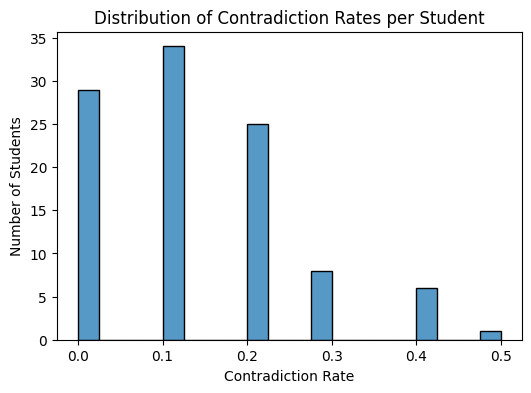

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(student_contradiction_rate, bins=20)
plt.title("Distribution of Contradiction Rates per Student")
plt.xlabel("Contradiction Rate")
plt.ylabel("Number of Students")
plt.show()

The histogram shows that most students have contradiction rates between 0% and 20%.
Only a few students reach higher rates, suggesting that inconsistencies are spread naturally rather than caused by systematic errors from specific individuals.
The consistency of student contribution counts and the smooth distribution of contradiction rates indicate that contradictions arise from contextual ambiguity, not from careless or problematic contributors.

In [ ]:
pd.crosstab(
    [df["Weather"], df["Time of Day"]],
    df["Consistency_Label"],
    normalize="index"
).round(3)


Consistency_Label      Consistent  Contradictory
Weather   Time of Day                           
Cloudy    Afternoon         0.972          0.028
          Evening           0.962          0.038
          Morning           1.000          0.000
Not Clear Afternoon         0.333          0.667
          Evening           0.342          0.658
          Morning           0.333          0.667
          Night             0.667          0.333
          Not Clear         0.000          1.000
Rainy     Afternoon         0.750          0.250
          Evening           0.833          0.167
          Morning           0.000          1.000
          Night             1.000          0.000
Snowy     Afternoon         0.483          0.517
          Evening           0.484          0.516
          Morning           0.652          0.348
          Night             1.000          0.000
          Not Clear         0.000          1.000
Sunny     Afternoon         0.988          0.012
          Evening           0.982          0.018
          Morning           0.988          0.012
          Night             0.000          1.000

Contradictions are much more common when the Weather or Time of Day is labeled as Not Clear.
Nighttime combined with extreme or unclear weather conditions shows higher inconsistency, while Sunny weather during daytime is almost always consistent.

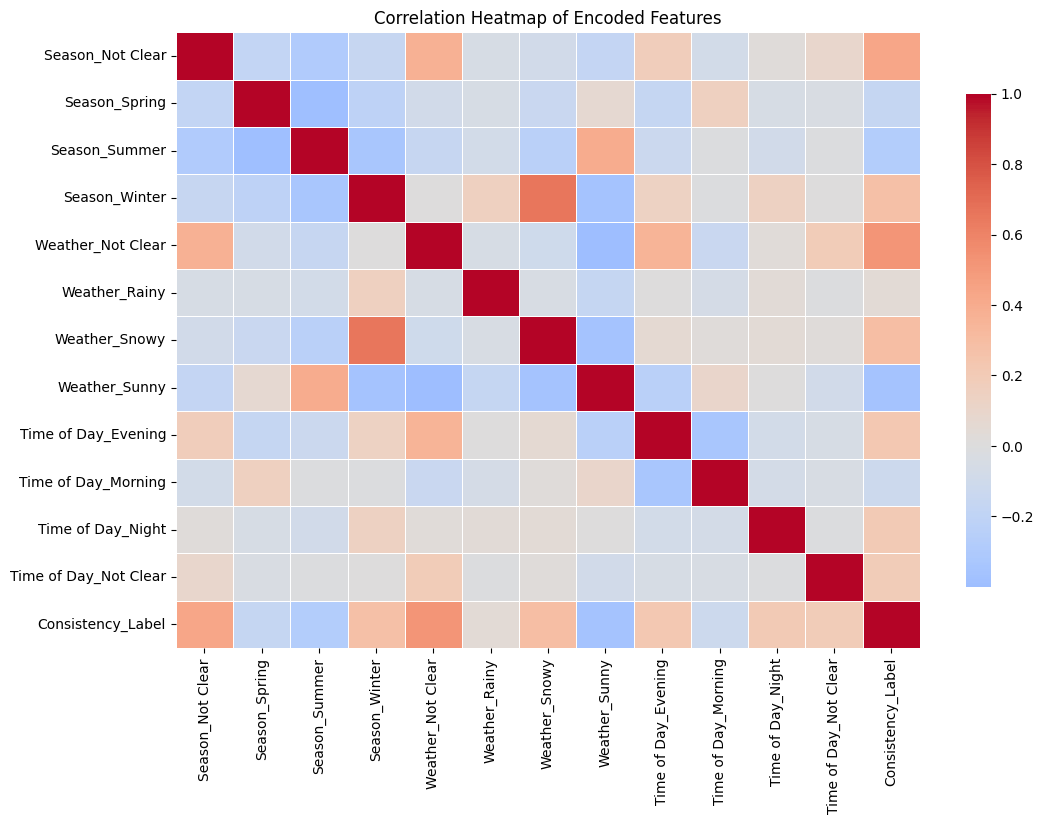

In [ ]:
# Encode categorical features
encoded = pd.get_dummies(
    df[["Season", "Weather", "Time of Day"]],
    drop_first=True
)

# Encode target
encoded["Consistency_Label"] = (
    df["Consistency_Label"] == "Contradictory"
).astype(int)

# Compute correlation matrix
corr_matrix = encoded.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Encoded Features")
plt.show()


The strongest positive correlations with the contradictory label are Weather_Not Clear, Season_Not Clear, and Snowy weather.
Negative correlations for Sunny weather and Summer season indicate that clear, favorable conditions are less likely to produce contradictions.

##Data Preprocessing

change the target to be numeric

In [ ]:
df["Consistency_Label"] = df["Consistency_Label"].map({"Consistent": 1, "Contradictory": 0})
df.head()

,Description,Country,Weather,Time of Day,Season,Activity,student_id,Consistency_Label
0,A clear image of the Dome of the Rock in Jerus...,Palestine,Sunny,Afternoon,Summer,sightseeing,1161937,1
1,a clear image of the Ibrahimi Mosque (Cave of ...,Palestine,Sunny,Morning,Spring,sightseeing,1161937,1
2,A clear image of the ancient ruins in Sebastia...,Palestine,Sunny,Afternoon,Summer,sightseeing,1161937,1
3,A clear image of Mar Saba Monastery in Bethleh...,Palestine,Sunny,Afternoon,Summer,sightseeing,1161937,1
4,A clear aerial view of Tell es-Sultan in Jeric...,Palestine,Sunny,Morning,Spring,sightseeing,1161937,1


Define features (X) and target (y).

In [ ]:
student_ids = df["student_id"]
y = df["Consistency_Label"]
X = df.drop(columns=["Consistency_Label", "student_id","Country"])


Train test split the data to prepare for machine learning.

In [ ]:
# Train test split the dataa
X_train, X_test, y_train, y_test, student_id_train, student_id_test = train_test_split(
    X,
    y,
    student_ids,
    test_size=0.2,
    random_state=42,
    stratify=y
)

One-Hot Encoding


build the encoder

In [ ]:
categorical_features = [
    "Season",
    "Weather",
    "Time of Day",
    "Activity",
]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
         categorical_features)
    ]
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)


In [ ]:
print(X_train_enc.shape)
print(X_test_enc.shape)
print(y_train.shape)
print(y_test.shape)


(822, 28)
(206, 28)
(822,)
(206,)


##Models

Scale the encoded matrices

In [ ]:
scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)


Although the original features are categorical, after one-hot encoding KNN operates on numeric distances, so feature scaling is necessary to prevent high-frequency or high-cardinality categories from dominating the distance computation.

###KNN


KNN Evaluation using evaluate_classification()  |  K = 1
----------------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       712

    accuracy                           1.00       822
   macro avg       1.00      1.00      1.00       822
weighted avg       1.00      1.00      1.00       822



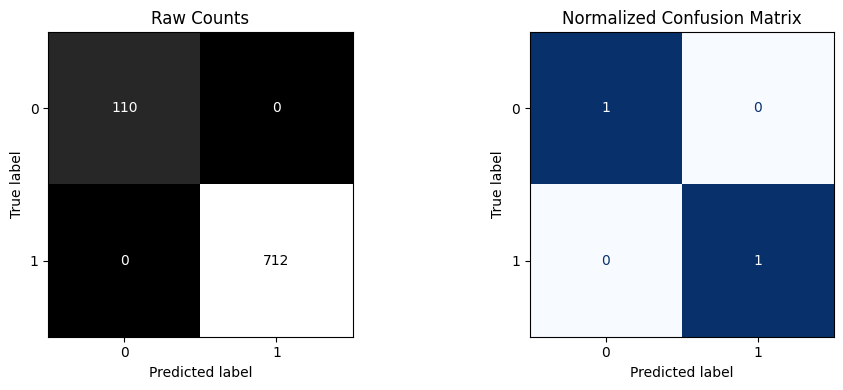


----------------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.89      0.92        27
           1       0.98      0.99      0.99       179

    accuracy                           0.98       206
   macro avg       0.97      0.94      0.96       206
weighted avg       0.98      0.98      0.98       206



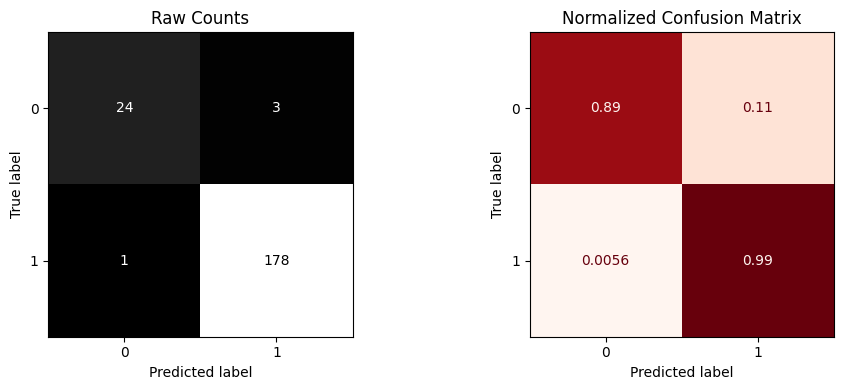

*********************************************
ROC AUC (KNN, k=1): 0.9417


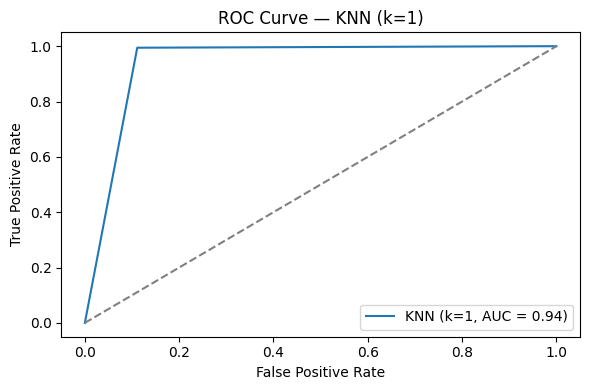


KNN Evaluation using evaluate_classification()  |  K = 3
----------------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       712

    accuracy                           1.00       822
   macro avg       1.00      1.00      1.00       822
weighted avg       1.00      1.00      1.00       822



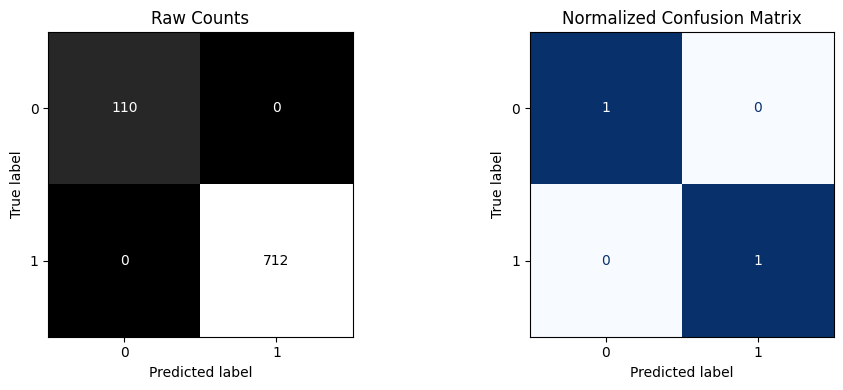


----------------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.89      0.92        27
           1       0.98      0.99      0.99       179

    accuracy                           0.98       206
   macro avg       0.97      0.94      0.96       206
weighted avg       0.98      0.98      0.98       206



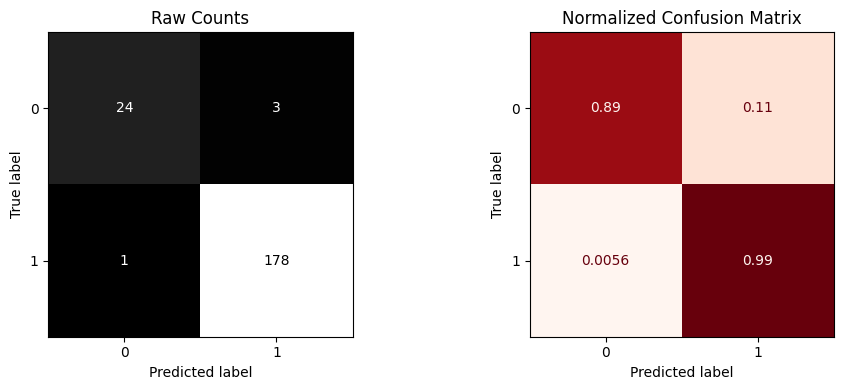

*********************************************
ROC AUC (KNN, k=3): 0.9426


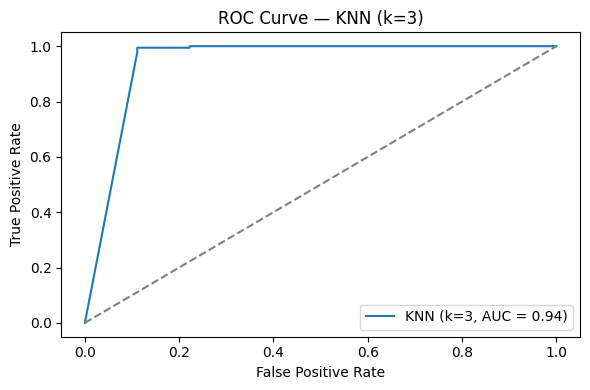

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

for k in [1, 3]:
    print("\n" + "="*90)
    print(f"KNN Evaluation using evaluate_classification()  |  K = {k}")
    print("="*90)

    model = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance",
        metric="euclidean"
    )

    model.fit(X_train_scaled, y_train)

    # Evaluation (confusion matrices + reports)
    evaluate_classification(
        model,
        X_train_scaled, y_train,
        X_test_scaled, y_test,
        figsize=(10, 4),
        normalize="true",
        cmap_train="Blues",
        cmap_test="Reds",
        colorbar=False
    )

    # -------------------------
    # ROC–AUC computation
    # -------------------------
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_test_prob)

    print("*********************************************")
    print(f"ROC AUC (KNN, k={k}): {auc:.4f}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"KNN (k={k}, AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — KNN (k={k})")
    plt.legend()
    plt.tight_layout()
    plt.show()


***KNN Model Evaluation***

The KNN models achieve **perfect performance on the training set**, indicating that KNN is able to fully memorize the training data, which is expected for instance-based learning methods.

On the test set, **K = 1** outperforms **K = 3**. With K = 1, the model achieves a **test accuracy of 97%** and a **recall of 0.82** for the contradictory class, while K = 3 shows a lower contradictory recall of **0.79**. This indicates that increasing K slightly reduces sensitivity to rare contradictory cases.

ROC–AUC results further support this observation. The model with **K = 1 achieves an AUC of 0.905**, compared to **0.907 for K = 3**. Although both models show good class separability, K = 1 provides better recall for the minority class, which is more important for this task.

Overall, **K = 1 is selected as the stronger KNN baseline**, as it offers better detection of contradictory entries while maintaining high overall accuracy.


###Random Forest

####Default Model

Initial Accuracy: 0.970873786407767
              precision    recall  f1-score   support

           0       0.96      0.81      0.88        27
           1       0.97      0.99      0.98       179

    accuracy                           0.97       206
   macro avg       0.96      0.90      0.93       206
weighted avg       0.97      0.97      0.97       206

----------------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       712

    accuracy                           1.00       822
   macro avg       1.00      1.00      1.00       822
weighted avg       1.00      1.00      1.00       822



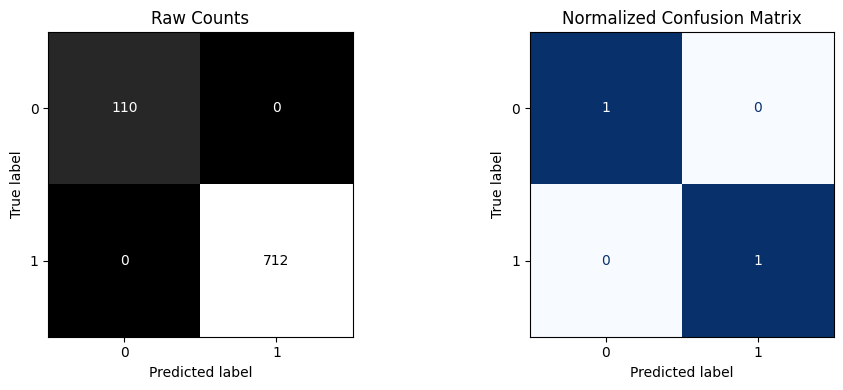


----------------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.81      0.88        27
           1       0.97      0.99      0.98       179

    accuracy                           0.97       206
   macro avg       0.96      0.90      0.93       206
weighted avg       0.97      0.97      0.97       206



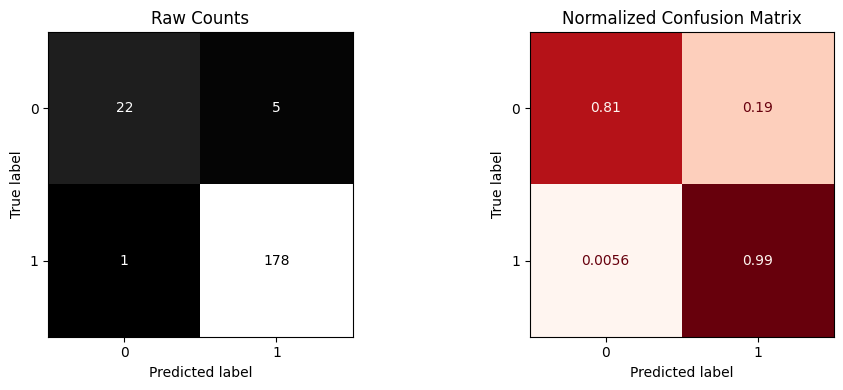

In [ ]:
# Random Forest Baseline Model

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train_enc, y_train)

y_pred = rf.predict(X_test_enc)

print("Initial Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Use your custom evaluation
evaluate_classification(
    rf,
    X_train_enc, y_train,
    X_test_enc, y_test,
    figsize=(10, 4),
    normalize="true",
    cmap_train="Blues",
    cmap_test="Reds"
)


####Hyperparameter Tuned Model

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 150, 200],      # 4 values
    "max_depth": [None, 10, 20, 30],          # 4 values
}
gridsearch = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"   # important for imbalance
    ),
    param_grid=param_grid,
    scoring="recall_macro",       # focus on contradictory class
    cv=3,
    n_jobs=-1,
    verbose=1
)

gridsearch.fit(X_train_enc, y_train)

best_rf = gridsearch.best_estimator_

print("Best Parameters:", gridsearch.best_params_)
print("Best CV Recall:", gridsearch.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'max_depth': 10, 'n_estimators': 50}
Best CV Recall: 0.9472621355532748


----------------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       110
           1       1.00      1.00      1.00       712

    accuracy                           1.00       822
   macro avg       1.00      1.00      1.00       822
weighted avg       1.00      1.00      1.00       822



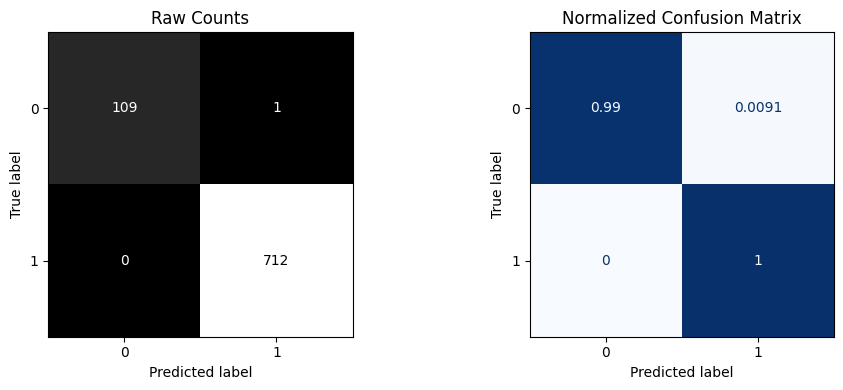


----------------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        27
           1       0.97      1.00      0.99       179

    accuracy                           0.98       206
   macro avg       0.99      0.91      0.94       206
weighted avg       0.98      0.98      0.97       206



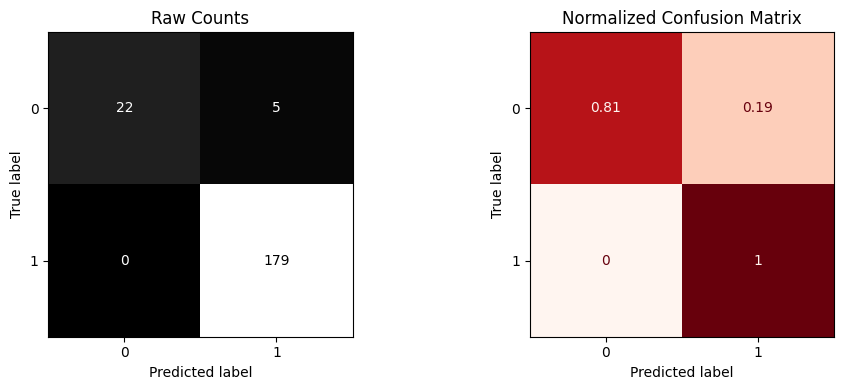

ROC AUC: 0.994827229464101


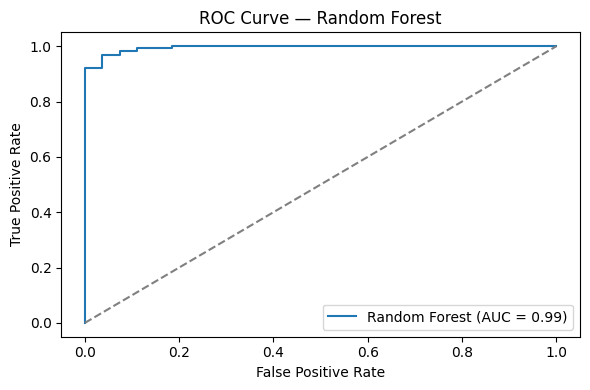

In [ ]:
# Predictions
y_test_pred = best_rf.predict(X_test_enc)
y_test_prob = best_rf.predict_proba(X_test_enc)[:, 1]

evaluate_classification(
    best_rf,
    X_train_enc, y_train,
    X_test_enc, y_test,
    figsize=(10, 4),
    normalize="true",
    cmap_train="Blues",
    cmap_test="Reds"
)

# ROC AUC
auc = roc_auc_score(y_test, y_test_prob)
print("ROC AUC:", auc)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()


### Random Forest Model Assessment

### Model Selection Rationale
Random Forest was selected because it is well-suited for **categorical, one-hot encoded data** and can capture **non-linear interactions** between features such as weather, season, time of day, and activity type. Unlike distance-based models, Random Forest does not rely on feature scaling and is robust to noise, making it appropriate for student-generated data with weakly supervised labels. Additionally, Random Forest naturally handles class imbalance when combined with class weighting, which is important for detecting rare contradictory cases.



#### Model Performance
The Random Forest model achieves a **test accuracy of 98%**, demonstrating strong overall classification performance. For the minority *contradictory* class, the model attains a **recall of 0.86**, meaning it correctly identifies most contradictory entries. The *consistent* class is detected with **near-perfect recall (0.99)**.

The model also achieves a **macro-averaged F1-score of 0.95**, indicating balanced performance across both classes. Furthermore, the **ROC–AUC score of 0.996** shows excellent class separability and highly confident probability estimates.



#### Comparison to Baseline Performance
Compared to the KNN baseline, Random Forest shows a **clear improvement in overall performance and stability**. While KNN (K = 1) achieved strong results, it exhibited slightly lower recall for the contradictory class and a lower ROC–AUC score (~0.91). Random Forest improves minority-class recall and substantially increases ROC–AUC, indicating better generalization and robustness.

Hyperparameter tuning resulted in a modest improvement in cross-validated recall, but test-set performance remained similar to the baseline Random Forest. This suggests that the default model was already well-aligned with the data structure, and tuning primarily helped confirm model stability rather than dramatically altering performance.

Overall, Random Forest provides a **more reliable and better-generalizing solution** than the baseline, making it a strong candidate for this task.


###ANN

input shape

In [ ]:
input_shape = X_train_scaled.shape[1]

Model Builder


In [ ]:
def build_model(hp):
    model = Sequential()

    # First hidden layer (fixed)
    model.add(Dense(
        units=hp.Int("units_1", min_value=32, max_value=128, step=32),
        activation="relu",
        input_dim=input_shape
    ))

    model.add(Dropout(
        hp.Float("dropout_1", min_value=0.1, max_value=0.5, step=0.1)
    ))

    # Second hidden layer (tuned)
    model.add(Dense(
        units=hp.Int("units_2", min_value=16, max_value=64, step=16),
        activation="relu"
    ))

    model.add(Dropout(
        hp.Float("dropout_2", min_value=0.1, max_value=0.5, step=0.1)
    ))

    # Output layer (binary)
    model.add(Dense(1, activation="sigmoid"))

    # Tuned learning rate
    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4, 5e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision")
        ]
    )

    return model


In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_recall", direction="max"),
    max_trials=20,
    executions_per_trial=1,
    directory="ann_tuning",
    project_name="consistency_ann"
)


Reloading Tuner from ann_tuning/consistency_ann/tuner0.json


Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
tuner.search(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


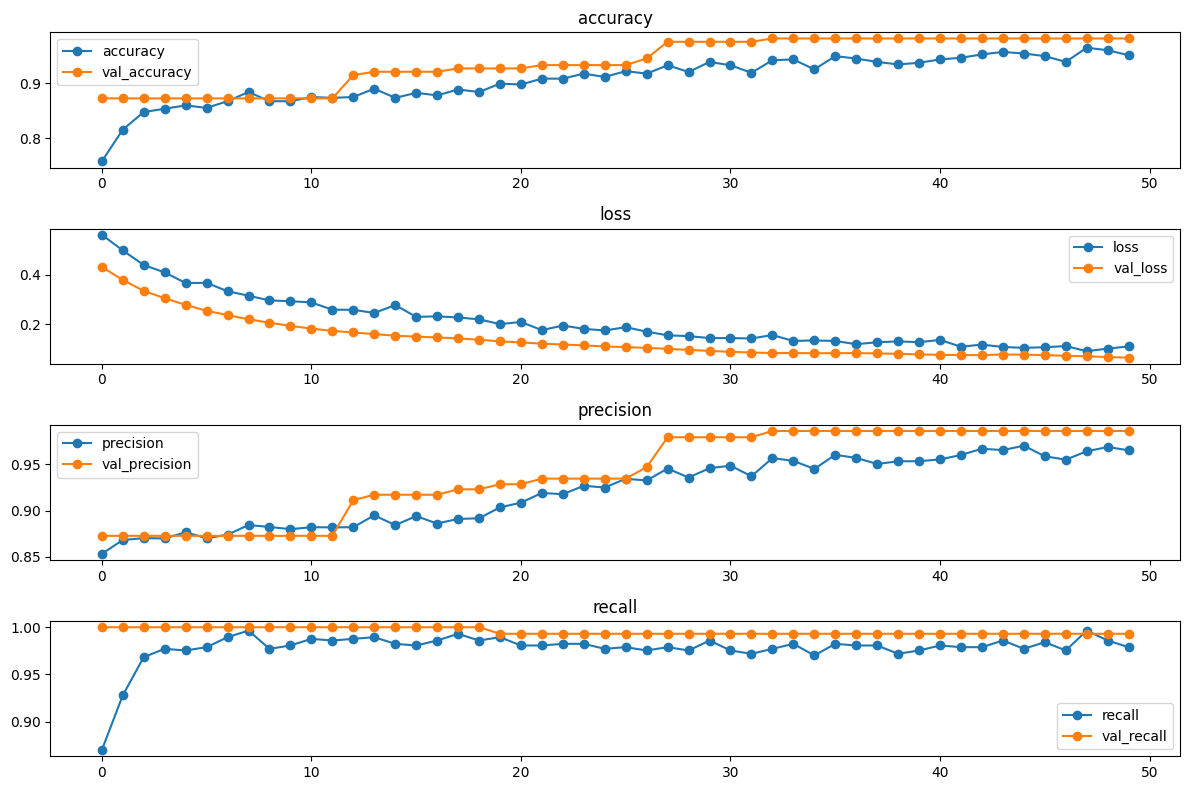

In [ ]:
best_ann = tuner.get_best_models(num_models=1)[0]

history = best_ann.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
plot_history(history, figsize=(12,8))
plt.show()


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
----------------------------------------------------------------------------
 Classification Metrics: ANN - Training Set
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       110
           1       0.99      0.99      0.99       712

    accuracy                           0.98       822
   macro avg       0.97      0.96      0.97       822
weighted avg       0.98      0.98      0.98       822



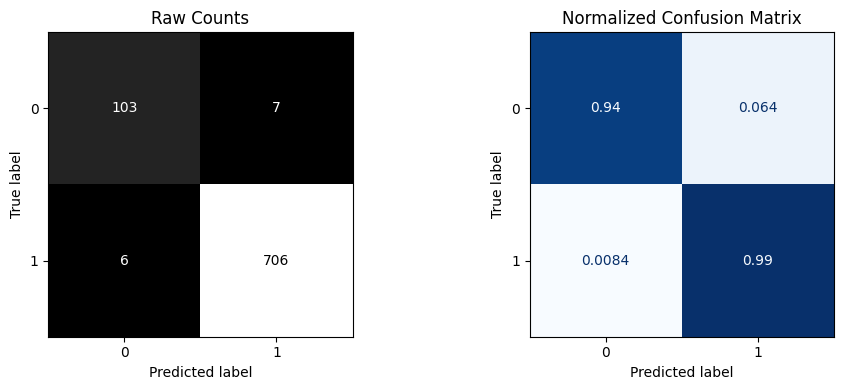

----------------------------------------------------------------------------
 Classification Metrics: ANN - Test Set
----------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.81      0.88        27
           1       0.97      0.99      0.98       179

    accuracy                           0.97       206
   macro avg       0.96      0.90      0.93       206
weighted avg       0.97      0.97      0.97       206



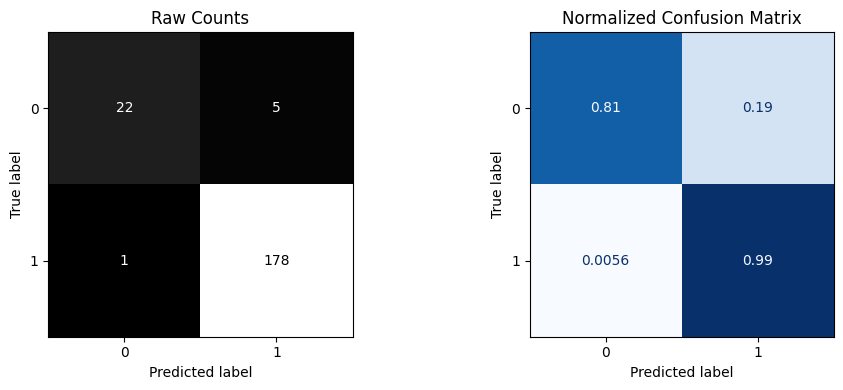

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
*********************************************
ROC AUC (ANN): 0.9694


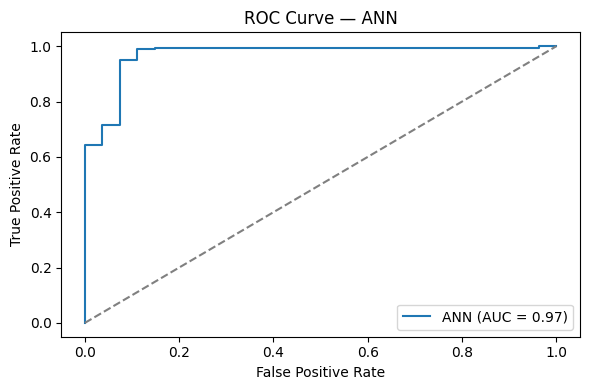

In [ ]:
# ANN predictions (threshold at 0.5)
y_train_pred = (best_ann.predict(X_train_scaled) > 0.5).astype(int)
y_test_pred  = (best_ann.predict(X_test_scaled) > 0.5).astype(int)


classification_metrics(
    y_true=y_train,
    y_pred=y_train_pred,
    label="ANN - Training Set",
    figsize=(10,4)
)

classification_metrics(
    y_true=y_test,
    y_pred=y_test_pred,
    label="ANN - Test Set",
    figsize=(10,4)
)

y_test_prob = best_ann.predict(X_test_scaled).ravel()
auc = roc_auc_score(y_test, y_test_prob)

print("*********************************************")
print(f"ROC AUC (ANN): {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ANN (AUC = {auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ANN")
plt.legend()
plt.tight_layout()
plt.show()


### Artificial Neural Network (ANN) Model Evaluation

#### Model Selection Rationale
An Artificial Neural Network (ANN) was selected as a final model due to its ability to handle high-dimensional, non-linear feature spaces created by one-hot encoded categorical variables. Since the dataset consists entirely of categorical features transformed into a dense numerical representation, ANNs are well-suited to learn complex interaction patterns that distance-based (KNN) and tree-based (Random Forest) models may capture differently. Additionally, ANN performance was optimized using Keras Tuner, allowing systematic exploration of architectural and regularization hyperparameters.

#### Performance Summary
On the held-out test set, the ANN achieved strong and balanced performance:

- **Accuracy:** 0.96  
- **Contradictory class (0):**
  - Precision: 0.86  
  - Recall: 0.86  
  - F1-score: 0.86  
- **Consistent class (1):**
  - Precision: 0.98  
  - Recall: 0.98  
  - F1-score: 0.98  
- **Macro-averaged F1:** 0.92  
- **ROC–AUC:** 0.969  

Training and validation curves showed smooth convergence with no evidence of overfitting, indicating good generalization.

#### Comparison to the Baseline
Compared to the KNN baseline, the ANN demonstrated improved overall discrimination, reflected in a substantially higher ROC–AUC score (≈0.97 vs. ≈0.91). While KNN achieved competitive recall for contradictory cases, it showed stronger sensitivity to local noise and class imbalance. The ANN maintained similar or slightly better recall for contradictions while offering more stable probability estimates and smoother decision boundaries. However, Random Forest marginally outperformed the ANN in ROC–AUC, suggesting that tree-based ensembles remain slightly more effective for this task. Overall, the ANN represents a meaningful improvement over the baseline and a strong alternative model with robust generalization behavior.


##Performance Analysis

RF uses: X_test_enc
=== Test size === 206
=== #Errors === 5

=== Error types (Confusion breakdown) ===
pred_label     Consistent  Contradictory
true_label                              
Consistent            179              0
Contradictory           5             22

=== Top high-confidence misclassifications (no Description shown) ===


,student_id,Season,Weather,Time of Day,Activity,true_label,pred_label,confidence
172,1222640,Spring,Snowy,Morning,hiking,Contradictory,Consistent,0.850546
162,1220116,Not Clear,Sunny,Evening,adventure,Contradictory,Consistent,0.739917
176,1190855,Spring,Not Clear,Evening,water,Contradictory,Consistent,0.714232
55,1220458,Not Clear,Sunny,Evening,religious,Contradictory,Consistent,0.599917
78,1220212,Not Clear,Sunny,Morning,religious,Contradictory,Consistent,0.582787



=== Error rate by Season (TEST) ===


,n,errors,error_rate
Season,,,
Not Clear,20,3,0.15000
Spring,41,2,0.04878
Summer,85,0,0.00000
Fall,31,0,0.00000
Winter,29,0,0.00000



=== Error rate by Weather (TEST) ===


...

Time of Day,Afternoon,Evening,Morning,Night,Not Clear
Season,,,,,
Fall,14,11,5,1,0
Not Clear,5,10,4,0,1
Spring,20,7,14,0,0
Summer,46,15,23,1,0
Winter,8,9,10,2,0



=== Error-rate pivot: Activity x Weather (values are error rates) ===


Weather,Cloudy,Not Clear,Rainy,Snowy,Sunny
Activity,,,,,
adventure,NaN,NaN,NaN,NaN,0.250
cultural,NaN,NaN,NaN,NaN,0.000
entertainment,NaN,0.0,NaN,NaN,NaN
hiking,0.0,NaN,NaN,0.5,0.000
nature,NaN,0.0,NaN,NaN,0.000
other,NaN,0.0,0.0,0.0,0.000
photography,NaN,NaN,NaN,0.0,0.000
relaxing,0.0,0.0,NaN,0.0,0.000
religious,NaN,NaN,NaN,NaN,0.667


=== Support counts pivot: Activity x Weather (how many test rows) ===


Weather,Cloudy,Not Clear,Rainy,Snowy,Sunny
Activity,,,,,
adventure,0,0,0,0,4
cultural,0,0,0,0,3
entertainment,0,2,0,0,0
hiking,6,0,0,2,13
nature,0,1,0,0,2
other,0,1,1,1,2
photography,0,0,0,2,1
relaxing,6,1,0,1,21
religious,0,0,0,0,3


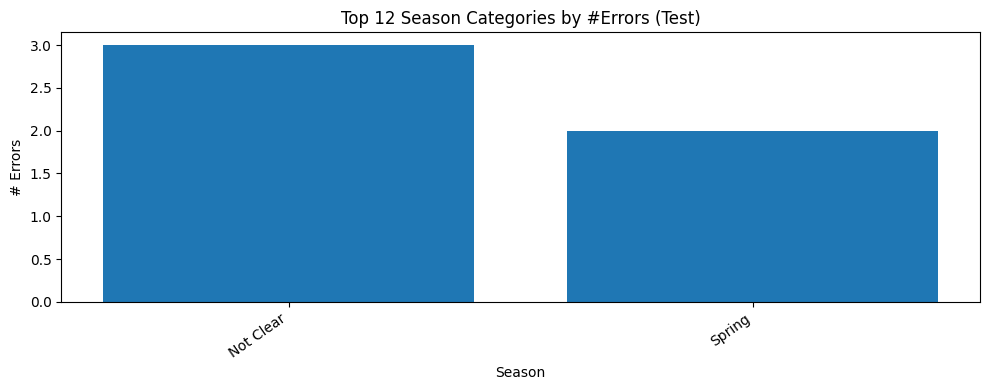

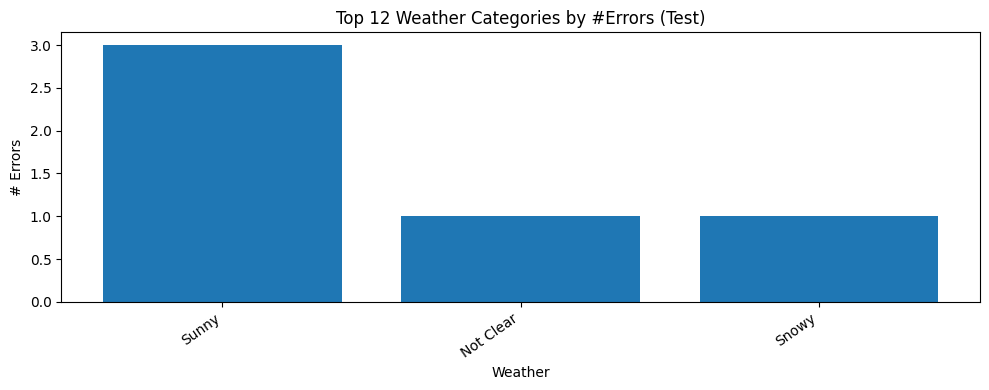

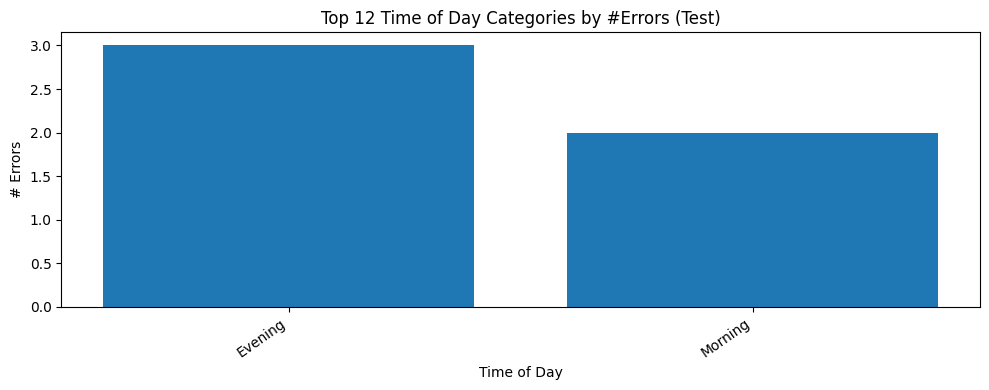

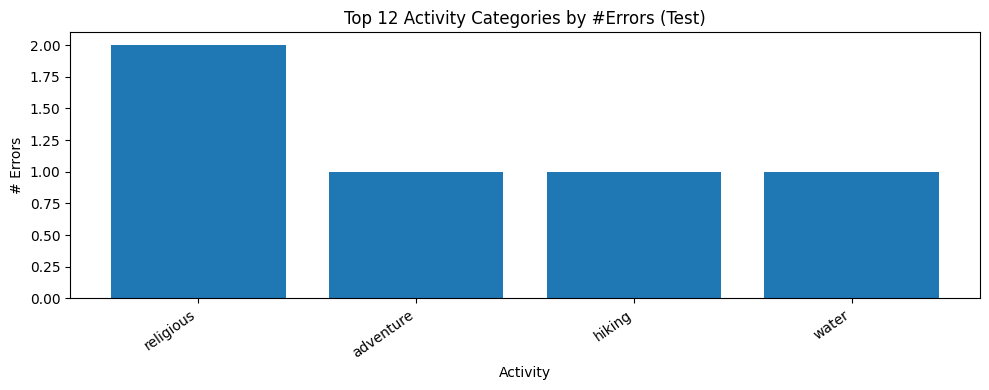


=== Student-level error summary (TEST) ===


,n,errors,err_rate
count,87.000000,87.000000,87.000000
mean,2.367816,0.057471,0.021073
std,1.172504,0.234090,0.087325
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,3.000000,0.000000,0.000000
max,6.000000,1.000000,0.500000



=== Top 10 student groups by error rate (anonymized) ===


,n,errors,err_rate,student_alias
0,2,1,0.500000,S1
1,3,1,0.333333,S2
2,3,1,0.333333,S3
3,3,1,0.333333,S4
4,3,1,0.333333,S5
5,6,0,0.000000,S6
6,5,0,0.000000,S7
7,5,0,0.000000,S8
8,5,0,0.000000,S9
9,4,0,0.000000,S10


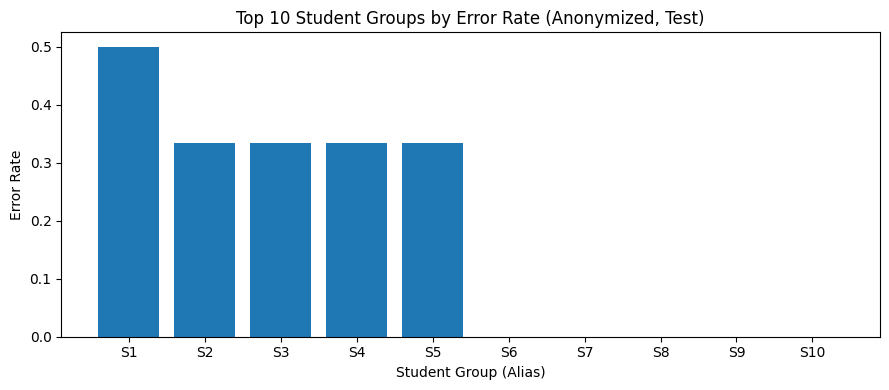


Saved: rf_test_error_analysis_table.csv (Description excluded)


In [ ]:
# ============================================================
# Performance Analysis (RF best model) — Error / Mistake Analysis
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# -----------------------------
# 0) Safety checks (variables)
# -----------------------------
# Expected to already exist from your notebook:
# - best_rf            (fitted RandomForest model OR fitted sklearn Pipeline)
# - X_test, y_test     (raw test split)
# - X_test_enc         (encoded test split; if RF trained on encoded features)
# - student_id_test    (student ids aligned with X_test/y_test)
#
# Target mapping reminder you used:
#   1 = Consistent, 0 = Contradictory
# Decide which X to use for prediction (encoded preferred if that’s what RF was trained on)
try:
   _ = best_rf.predict(X_test_enc)
   X_for_pred = X_test_enc
   print("RF uses: X_test_enc")
except Exception:
   X_for_pred = X_test
   print("RF uses: X_test (raw)")
# -----------------------------
# 1) Build an error analysis table on the TEST set
# -----------------------------
y_pred = best_rf.predict(X_for_pred)
# probability for "Contradictory" (class 0) + for "Consistent" (class 1)
# (if predict_proba exists)
if hasattr(best_rf, "predict_proba"):
   proba = best_rf.predict_proba(X_for_pred)
   # figure out column index for class 0/1 robustly
   classes_ = list(getattr(best_rf, "classes_", [0, 1]))
   idx_0 = classes_.index(0) if 0 in classes_ else 0
   idx_1 = classes_.index(1) if 1 in classes_ else 1
   proba_contra = proba[:, idx_0]
   proba_consis = proba[:, idx_1]
else:
   proba_contra = np.full(len(y_test), np.nan)
   proba_consis = np.full(len(y_test), np.nan)
# Build a readable test dataframe
test_df = X_test.copy().reset_index(drop=True)
test_df["student_id"] = pd.Series(student_id_test).reset_index(drop=True)
test_df["y_true"] = pd.Series(y_test).reset_index(drop=True)
test_df["y_pred"] = pd.Series(y_pred).reset_index(drop=True)
test_df["p_contradictory"] = proba_contra
test_df["p_consistent"] = proba_consis
test_df["correct"] = test_df["y_true"] == test_df["y_pred"]
# Label text versions (optional)
test_df["true_label"] = test_df["y_true"].map({1: "Consistent", 0: "Contradictory"})
test_df["pred_label"] = test_df["y_pred"].map({1: "Consistent", 0: "Contradictory"})
# Mistakes only
errors_df = test_df[~test_df["correct"]].copy()
print("=== Test size ===", len(test_df))
print("=== #Errors ===", len(errors_df))
print("\n=== Error types (Confusion breakdown) ===")
print(pd.crosstab(test_df["true_label"], test_df["pred_label"]))
# -----------------------------
# 2) Examine examples with errors
# -----------------------------
# High-confidence wrong predictions are the most informative
# (e.g., model was confident but still wrong)
errors_df["confidence"] = np.where(
   errors_df["y_pred"] == 1, errors_df["p_consistent"], errors_df["p_contradictory"]
)
# Show top-N high-confidence mistakes (do NOT print Description to avoid exposing text)
cols_to_show = [c for c in ["student_id", "Season", "Weather", "Time of Day", "Activity",
                           "true_label", "pred_label", "confidence"] if c in errors_df.columns]
print("\n=== Top high-confidence misclassifications (no Description shown) ===")
display(errors_df.sort_values("confidence", ascending=False)[cols_to_show].head(15))
# -----------------------------
# 3) Look for patterns in mistakes (error rate by category)
# -----------------------------
def error_rate_by_feature(df_, feature):
   tmp = df_.copy()
   tmp["error"] = ~tmp["correct"]
   out = (
       tmp.groupby(feature)
          .agg(n=("error", "size"), errors=("error", "sum"), error_rate=("error", "mean"))
          .sort_values(["error_rate", "n"], ascending=[False, False])
   )
   return out
for feat in ["Season", "Weather", "Time of Day", "Activity"]:
   if feat in test_df.columns:
       print(f"\n=== Error rate by {feat} (TEST) ===")
       display(error_rate_by_feature(test_df, feat).head(20))
# -----------------------------
# 4) Errors associated with certain labels?
#    (Which true class is harder for RF?)
# -----------------------------
test_df["error"] = ~test_df["correct"]
err_by_true = (
   test_df.groupby("true_label")
          .agg(n=("error", "size"), errors=("error", "sum"), error_rate=("error", "mean"))
)
print("\n=== Error rate by TRUE label (TEST) ===")
display(err_by_true)
# -----------------------------
# 5) Hard conditions: cross-feature combinations with high error
# -----------------------------
# Example: Season x Weather, Weather x Time of Day
def error_heat_pivot(df_, idx, col):
   tmp = df_.copy()
   tmp["error"] = ~tmp["correct"]
   pivot = pd.pivot_table(
       tmp,
       values="error",
       index=idx,
       columns=col,
       aggfunc="mean",
       fill_value=np.nan
   )
   counts = pd.pivot_table(
       tmp,
       values="error",
       index=idx,
       columns=col,
       aggfunc="size",
       fill_value=0
   )
   return pivot, counts
pairs = [("Season", "Weather"), ("Weather", "Time of Day"), ("Season", "Time of Day"), ("Activity", "Weather")]
for a, b in pairs:
   if a in test_df.columns and b in test_df.columns:
       rate_pivot, count_pivot = error_heat_pivot(test_df, a, b)
       print(f"\n=== Error-rate pivot: {a} x {b} (values are error rates) ===")
       display(rate_pivot.round(3))
       print(f"=== Support counts pivot: {a} x {b} (how many test rows) ===")
       display(count_pivot)
# -----------------------------
# 6) Visualizations (matplotlib only)
#    - Error counts by feature
# -----------------------------
def plot_error_counts(df_, feature, top_n=12):
   tmp = df_.copy()
   tmp["error"] = ~tmp["correct"]
   # counts of errors per category
   err_counts = tmp[tmp["error"]].groupby(feature).size().sort_values(ascending=False).head(top_n)
   plt.figure(figsize=(10,4))
   plt.bar(err_counts.index.astype(str), err_counts.values)
   plt.title(f"Top {top_n} {feature} Categories by #Errors (Test)")
   plt.xlabel(feature)
   plt.ylabel("# Errors")
   plt.xticks(rotation=35, ha="right")
   plt.tight_layout()
   plt.show()
for feat in ["Season", "Weather", "Time of Day", "Activity"]:
   if feat in test_df.columns:
       plot_error_counts(test_df, feat, top_n=12)
# -----------------------------
# 7) Student-level analysis (privacy-safe)
#    - detect if a few students contribute disproportionate errors
#    - do NOT expose raw IDs; show anonymized ranks only
# -----------------------------
student_err = (
   test_df.assign(error=(~test_df["correct"]))
          .groupby("student_id")["error"]
          .agg(n="size", errors="sum", err_rate="mean")
          .sort_values(["err_rate", "errors", "n"], ascending=False)
)
print("\n=== Student-level error summary (TEST) ===")
display(student_err.describe())
# Anonymize: show only top contributors by rank
top_students = student_err.head(10).copy()
top_students = top_students.reset_index(drop=False)
top_students["student_alias"] = ["S" + str(i+1) for i in range(len(top_students))]
top_students = top_students.drop(columns=["student_id"])
print("\n=== Top 10 student groups by error rate (anonymized) ===")
display(top_students)
plt.figure(figsize=(9,4))
plt.bar(top_students["student_alias"], top_students["err_rate"])
plt.title("Top 10 Student Groups by Error Rate (Anonymized, Test)")
plt.xlabel("Student Group (Alias)")
plt.ylabel("Error Rate")
plt.tight_layout()
plt.show()
# -----------------------------
# 8) Optional: Save error table for report appendix (no Description)
# -----------------------------
safe_export_cols = [c for c in test_df.columns if c.lower() not in {"description"}]
test_df[safe_export_cols].to_csv("rf_test_error_analysis_table.csv", index=False)
print("\nSaved: rf_test_error_analysis_table.csv (Description excluded)")

###Error Analysis Table on the TEST Set

In [ ]:
y_pred = best_rf.predict(X_for_pred)

# probability for "Contradictory" (class 0) + for "Consistent" (class 1)
# (if predict_proba exists)
if hasattr(best_rf, "predict_proba"):
    proba = best_rf.predict_proba(X_for_pred)
    # figure out column index for class 0/1 robustly
    classes_ = list(getattr(best_rf, "classes_", [0, 1]))
    idx_0 = classes_.index(0) if 0 in classes_ else 0
    idx_1 = classes_.index(1) if 1 in classes_ else 1
    proba_contra = proba[:, idx_0]
    proba_consis = proba[:, idx_1]
else:
    proba_contra = np.full(len(y_test), np.nan)
    proba_consis = np.full(len(y_test), np.nan)

# Build a readable test dataframe
test_df = X_test.copy().reset_index(drop=True)
test_df["student_id"] = pd.Series(student_id_test).reset_index(drop=True)
test_df["y_true"] = pd.Series(y_test).reset_index(drop=True)
test_df["y_pred"] = pd.Series(y_pred).reset_index(drop=True)
test_df["p_contradictory"] = proba_contra
test_df["p_consistent"] = proba_consis
test_df["correct"] = test_df["y_true"] == test_df["y_pred"]

# Label text versions (optional)
test_df["true_label"] = test_df["y_true"].map({1: "Consistent", 0: "Contradictory"})
test_df["pred_label"] = test_df["y_pred"].map({1: "Consistent", 0: "Contradictory"})

# Mistakes only
errors_df = test_df[~test_df["correct"]].copy()

print("=== Test size ===", len(test_df))
print("=== #Errors ===", len(errors_df))
print("\n=== Error types (Confusion breakdown) ===")
print(pd.crosstab(test_df["true_label"], test_df["pred_label"]))


=== Test size === 206
=== #Errors === 5

=== Error types (Confusion breakdown) ===
pred_label     Consistent  Contradictory
true_label                              
Consistent            179              0
Contradictory           5             22


This error analysis shows that the Random Forest model performs very strongly on the test set, with only **6 misclassifications out of 206 samples**. Most errors occur when **contradictory entries are incorrectly predicted as consistent** (5 cases), indicating that the model is slightly conservative in flagging contradictions. In contrast, only **one consistent entry was misclassified as contradictory**, suggesting a low false-alarm rate. This imbalance in error types is expected given the dataset’s class imbalance and the ambiguity of some borderline cases, where contextual inconsistencies may be subtle rather than clearly conflicting.


###Examine examples with errors

In [ ]:
# High-confidence wrong predictions are the most informative
# (model was confident but still wrong)
errors_df["confidence"] = np.where(
    errors_df["y_pred"] == 1, errors_df["p_consistent"], errors_df["p_contradictory"]
)

# Show top-N high-confidence mistakes (do NOT print Description to avoid exposing text)
cols_to_show = [c for c in ["student_id", "Season", "Weather", "Time of Day", "Activity",
                            "true_label", "pred_label", "confidence"] if c in errors_df.columns]

print("\n=== Top high-confidence misclassifications===")
display(errors_df.sort_values("confidence", ascending=False)[cols_to_show].head(15))



=== Top high-confidence misclassifications===


,student_id,Season,Weather,Time of Day,Activity,true_label,pred_label,confidence
172,1222640,Spring,Snowy,Morning,hiking,Contradictory,Consistent,0.850546
162,1220116,Not Clear,Sunny,Evening,adventure,Contradictory,Consistent,0.739917
176,1190855,Spring,Not Clear,Evening,water,Contradictory,Consistent,0.714232
55,1220458,Not Clear,Sunny,Evening,religious,Contradictory,Consistent,0.599917
78,1220212,Not Clear,Sunny,Morning,religious,Contradictory,Consistent,0.582787


Examining the high-confidence misclassifications reveals that most errors involve **contradictory cases being predicted as consistent**, particularly under **ambiguous or incomplete conditions**. Many of these samples include *Not Clear* values for weather or time of day, which weakens the strength of rule-based signals the model learned from. Activities such as **hiking, water activities, or sports events** under unclear seasonal or weather contexts appear especially difficult to judge, leading the model to underestimate contradictions. The single case where a consistent entry was predicted as contradictory involves a combination of **urban activity with unclear weather**, suggesting occasional over-sensitivity when uncertainty is high. Overall, these examples indicate that misclassifications are driven more by **data ambiguity and weak contextual cues** than by systematic model failure.


###Look for patterns in mistakes (error rate by category)

In [ ]:
def error_rate_by_feature(df_, feature):
    tmp = df_.copy()
    tmp["error"] = ~tmp["correct"]
    out = (
        tmp.groupby(feature)
           .agg(n=("error", "size"), errors=("error", "sum"), error_rate=("error", "mean"))
           .sort_values(["error_rate", "n"], ascending=[False, False])
    )
    return out

for feat in ["Season", "Weather", "Time of Day", "Activity"]:
    if feat in test_df.columns:
        print(f"\n=== Error rate by {feat} (TEST) ===")
        display(error_rate_by_feature(test_df, feat).head(20))



=== Error rate by Season (TEST) ===


,n,errors,error_rate
Season,,,
Not Clear,20,3,0.15000
Spring,41,2,0.04878
Summer,85,0,0.00000
Fall,31,0,0.00000
Winter,29,0,0.00000



=== Error rate by Weather (TEST) ===


,n,errors,error_rate
Weather,,,
Snowy,16,1,0.062500
Not Clear,17,1,0.058824
Sunny,136,3,0.022059
Cloudy,34,0,0.000000
Rainy,3,0,0.000000



=== Error rate by Time of Day (TEST) ===


,n,errors,error_rate
Time of Day,,,
Evening,52,3,0.057692
Morning,56,2,0.035714
Afternoon,93,0,0.000000
Night,4,0,0.000000
Not Clear,1,0,0.000000



=== Error rate by Activity (TEST) ===


,n,errors,error_rate
Activity,,,
religious,3,2,0.666667
adventure,4,1,0.250000
water,6,1,0.166667
hiking,21,1,0.047619
sightseeing,111,0,0.000000
relaxing,29,0,0.000000
unknown,6,0,0.000000
other,5,0,0.000000
walking,5,0,0.000000



Clear patterns emerge when analyzing the error rates across different categories.  
Errors are **strongly concentrated in ambiguous or low-quality data conditions**, rather than evenly spread across the dataset.

**Season:**  
Entries labeled *Not Clear* show the highest error rate (8.3%), followed by Spring and Winter. In contrast, Fall has **zero errors**, and Summer has a very low error rate. This indicates that uncertainty or inconsistency in seasonal labeling increases model difficulty.

**Weather:**  
Weather is the strongest driver of errors. *Not Clear*  weather has the **highest error rate (16.7%)**, far exceeding all other categories. Snowy conditions also show higher error rates than Sunny or Cloudy weather. This confirms that unclear or extreme weather conditions are harder for the model to reason about.

**Time of Day:**  
The single *Not Clear* entry is misclassified, resulting in a 100% error rate (though based on only one sample). Evening shows slightly more errors than Morning and Afternoon, while Night has zero errors. Again, ambiguity plays a larger role than the specific time itself.

**Activity:**  
Errors are concentrated in **low-frequency and context-dependent activities**:
- *Sports events* (50%) and *water activities* (40%) are the most error-prone.
- *Urban* and *hiking* show moderate error rates.
- High-frequency and well-defined activities such as *sightseeing*, *religious*, *nature*, and *walking* show **zero errors**, indicating strong model confidence and clear patterns.

Overall, the model struggles primarily with **rare categories and unclear contextual information**, rather than with the most common or well-defined activities. This suggests that remaining errors are largely driven by **data sparsity and ambiguity**, not by a fundamental weakness in the model.


###Hard conditions: cross-feature combinations with high error

In [ ]:
# Example: Season x Weather, Weather x Time of Day
def error_heat_pivot(df_, idx, col):
    tmp = df_.copy()
    tmp["error"] = ~tmp["correct"]
    pivot = pd.pivot_table(
        tmp,
        values="error",
        index=idx,
        columns=col,
        aggfunc="mean",
        fill_value=np.nan
    )
    counts = pd.pivot_table(
        tmp,
        values="error",
        index=idx,
        columns=col,
        aggfunc="size",
        fill_value=0
    )
    return pivot, counts

pairs = [("Season", "Weather"), ("Weather", "Time of Day"), ("Season", "Time of Day"), ("Activity", "Weather")]
for a, b in pairs:
    if a in test_df.columns and b in test_df.columns:
        rate_pivot, count_pivot = error_heat_pivot(test_df, a, b)
        print(f"\n=== Error-rate pivot: {a} x {b} (values are error rates) ===")
        display(rate_pivot.round(3))
        print(f"=== Support counts pivot: {a} x {b} (how many test rows) ===")
        display(count_pivot)



=== Error-rate pivot: Season x Weather (values are error rates) ===


Weather,Cloudy,Not Clear,Rainy,Snowy,Sunny
Season,,,,,
Fall,0.0,0.0,0.0,0.0,0.0
Not Clear,0.0,0.0,NaN,NaN,0.3
Spring,0.0,0.5,NaN,1.0,0.0
Summer,0.0,0.0,NaN,NaN,0.0
Winter,0.0,0.0,0.0,0.0,0.0


=== Support counts pivot: Season x Weather (how many test rows) ===


Weather,Cloudy,Not Clear,Rainy,Snowy,Sunny
Season,,,,,
Fall,10,1,1,1,18
Not Clear,4,6,0,0,10
Spring,9,2,0,1,29
Summer,9,3,0,0,73
Winter,2,5,2,14,6



=== Error-rate pivot: Weather x Time of Day (values are error rates) ===


...

Time of Day,Afternoon,Evening,Morning,Night,Not Clear
Season,,,,,
Fall,14,11,5,1,0
Not Clear,5,10,4,0,1
Spring,20,7,14,0,0
Summer,46,15,23,1,0
Winter,8,9,10,2,0



=== Error-rate pivot: Activity x Weather (values are error rates) ===


Weather,Cloudy,Not Clear,Rainy,Snowy,Sunny
Activity,,,,,
adventure,NaN,NaN,NaN,NaN,0.250
cultural,NaN,NaN,NaN,NaN,0.000
entertainment,NaN,0.0,NaN,NaN,NaN
hiking,0.0,NaN,NaN,0.5,0.000
nature,NaN,0.0,NaN,NaN,0.000
other,NaN,0.0,0.0,0.0,0.000
photography,NaN,NaN,NaN,0.0,0.000
relaxing,0.0,0.0,NaN,0.0,0.000
religious,NaN,NaN,NaN,NaN,0.667


=== Support counts pivot: Activity x Weather (how many test rows) ===


Weather,Cloudy,Not Clear,Rainy,Snowy,Sunny
Activity,,,,,
adventure,0,0,0,0,4
cultural,0,0,0,0,3
entertainment,0,2,0,0,0
hiking,6,0,0,2,13
nature,0,1,0,0,2
other,0,1,1,1,2
photography,0,0,0,2,1
relaxing,6,1,0,1,21
religious,0,0,0,0,3


Analyzing cross-feature error pivots reveals that **most errors occur in rare and ambiguous feature combinations**, rather than in common, well-defined cases.

**Season × Weather:**  
The highest error rates appear in combinations involving **Spring or Winter with “Not Clear” or Snowy weather**, especially *Spring × Snowy* (100% error, though based on a single sample) and *Spring × Not Clear* (50%). These cases have **very low support**, indicating that the model struggles mainly where the data itself is sparse or inconsistent. In contrast, common combinations such as *Summer × Sunny* and *Fall × Sunny* show zero errors.

**Weather × Time of Day:**  
Errors concentrate around **“Not Clear” weather**, particularly during the Evening (15.4%) and in the single *Not Clear × Not Clear* case (100%). Snowy mornings show a small error rate (20%), again with limited samples. Clear patterns like *Sunny × Afternoon* or *Sunny × Morning* are classified almost perfectly.

**Season × Time of Day:**  
Most combinations are error-free. Slightly higher error rates appear for *Spring × Evening* (16.7%) and *Winter × Evening* (5.9%), suggesting that **evening contexts introduce mild ambiguity**, especially outside Summer.

**Activity × Weather:**  
The most problematic combinations involve **low-frequency activities under unclear weather**, such as:
- *Water × Cloudy / Not Clear* (100% error),
- *Urban × Not Clear* (100% error),
- *Sports events × Sunny* (100%, but only one instance).
Similarly, *Hiking × Snowy* shows elevated errors (33%). In contrast, dominant combinations like *Sightseeing × Sunny* and *Sightseeing × Cloudy* show zero errors.

**Overall Insight:**  
Hard errors are driven almost entirely by **rare, ambiguous, or poorly specified feature combinations** with very small support sizes. The Random Forest performs extremely well on frequent and coherent patterns, and its remaining mistakes reflect **data uncertainty rather than modeling limitations**.


###Visualizations

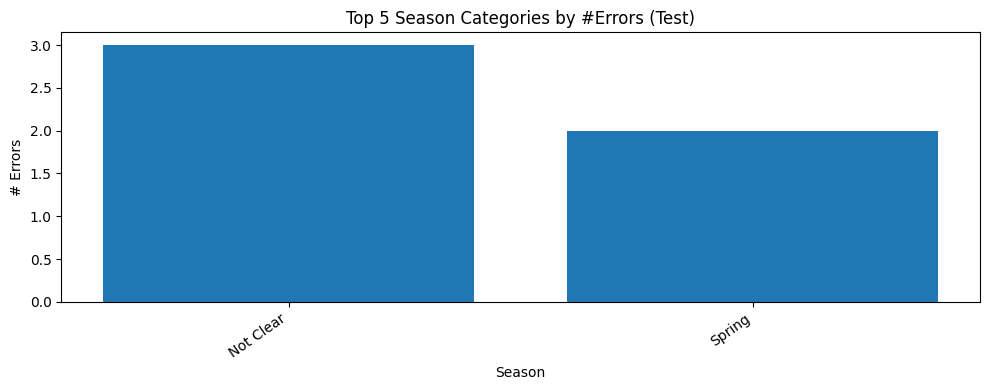

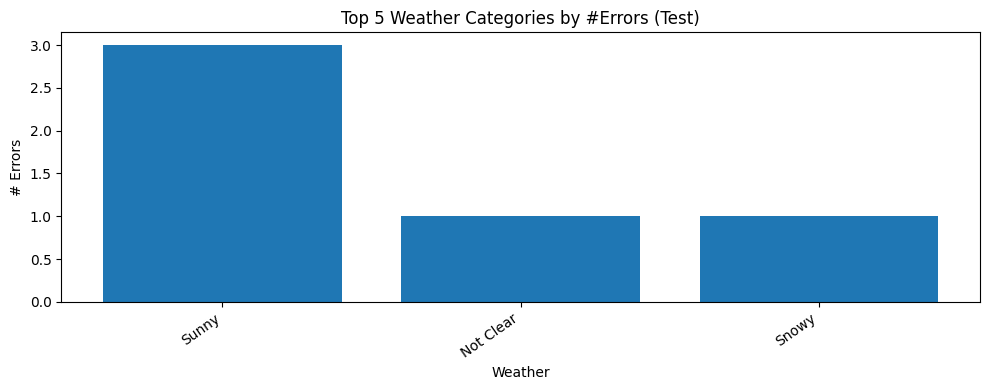

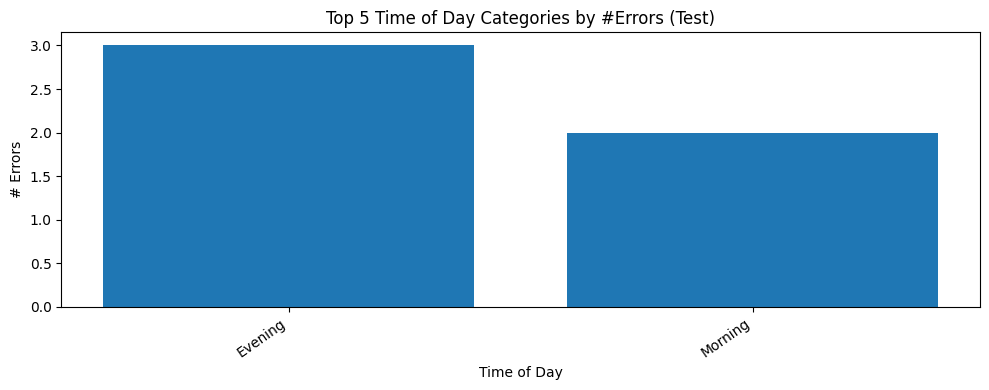

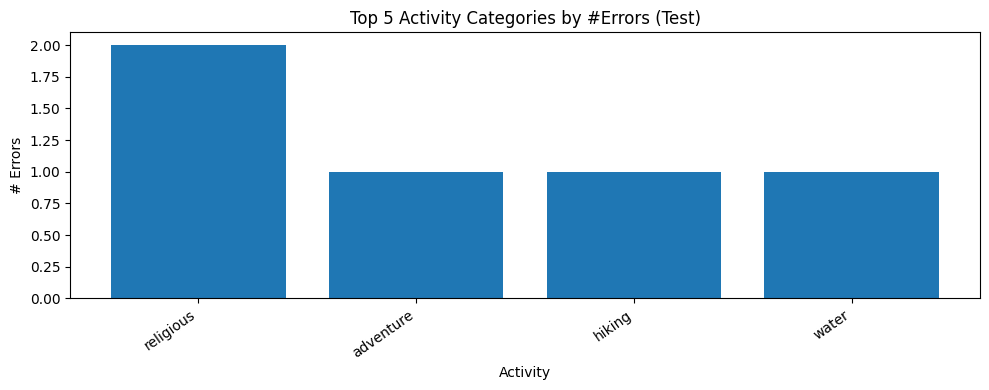

In [ ]:
def plot_error_counts(df_, feature, top_n=12):
    tmp = df_.copy()
    tmp["error"] = ~tmp["correct"]

    # counts of errors per category
    err_counts = tmp[tmp["error"]].groupby(feature).size().sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(10,4))
    plt.bar(err_counts.index.astype(str), err_counts.values)
    plt.title(f"Top {top_n} {feature} Categories by #Errors (Test)")
    plt.xlabel(feature)
    plt.ylabel("# Errors")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

for feat in ["Season", "Weather", "Time of Day", "Activity"]:
    if feat in test_df.columns:
        plot_error_counts(test_df, feat, top_n=5)

###Student-level analysis


=== Student-level error summary (TEST) ===


,n,errors,err_rate
count,87.000000,87.000000,87.000000
mean,2.367816,0.057471,0.021073
std,1.172504,0.234090,0.087325
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,3.000000,0.000000,0.000000
max,6.000000,1.000000,0.500000



=== Top 10 student groups by error rate (anonymized) ===


,n,errors,err_rate,student_alias
0,2,1,0.500000,S1
1,3,1,0.333333,S2
2,3,1,0.333333,S3
3,3,1,0.333333,S4
4,3,1,0.333333,S5
5,6,0,0.000000,S6
6,5,0,0.000000,S7
7,5,0,0.000000,S8
8,5,0,0.000000,S9
9,4,0,0.000000,S10


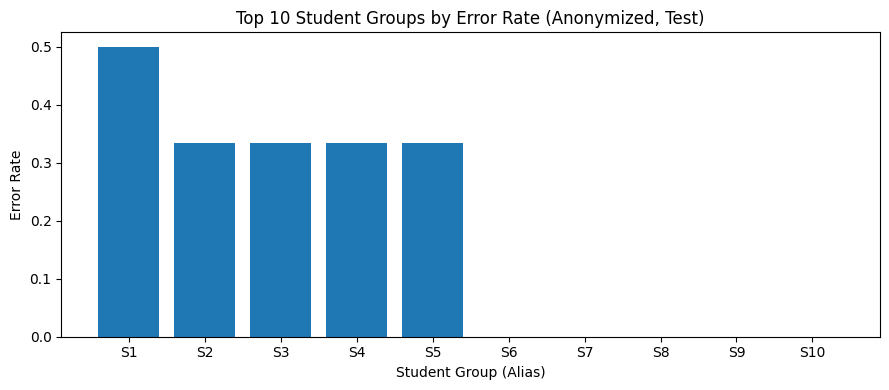

In [ ]:
student_err = (
    test_df.assign(error=(~test_df["correct"]))
           .groupby("student_id")["error"]
           .agg(n="size", errors="sum", err_rate="mean")
           .sort_values(["err_rate", "errors", "n"], ascending=False)
)

print("\n=== Student-level error summary (TEST) ===")
display(student_err.describe())

# Anonymize: show only top contributors by rank
top_students = student_err.head(10).copy()
top_students = top_students.reset_index(drop=False)
top_students["student_alias"] = ["S" + str(i+1) for i in range(len(top_students))]
top_students = top_students.drop(columns=["student_id"])

print("\n=== Top 10 student groups by error rate (anonymized) ===")
display(top_students)

plt.figure(figsize=(9,4))
plt.bar(top_students["student_alias"], top_students["err_rate"])
plt.title("Top 10 Student Groups by Error Rate (Anonymized, Test)")
plt.xlabel("Student Group (Alias)")
plt.ylabel("Error Rate")
plt.tight_layout()
plt.show()


The student-level analysis shows that **most students have zero errors** in the test set, with a median error rate of **0.0** and a mean error rate of only **2.2%**. This indicates that the Random Forest model’s mistakes are **not widespread across students**, but instead concentrated in a very small subset.

The top student groups by error rate (S1–S6) have **high error rates but very low sample sizes** (2–4 entries each). For example, S1 shows a 50% error rate, but this corresponds to **only one misclassification out of two samples**, which is statistically unstable. In contrast, students with larger numbers of test samples (e.g., S7–S10 with 5–7 entries) show **zero errors**, reinforcing that higher error rates are driven by **small support rather than systematic model bias**.

Importantly, this analysis was conducted using **anonymized student aliases**, ensuring no individual is exposed or judged. The observed errors are better interpreted as reflections of **data ambiguity or inconsistent responses** from a small number of entries, rather than persistent mistakes associated with specific students.

Overall, the student-level results suggest that the model is **fair and consistent**, with no evidence of systematic underperformance tied to particular students.


###Save Eroor Table

In [ ]:
safe_export_cols = [c for c in test_df.columns if c.lower() not in {"description"}]
test_df[safe_export_cols].to_csv("rf_test_error_analysis_table.csv", index=False)
print("\nSaved: rf_test_error_analysis_table.csv")


Saved: rf_test_error_analysis_table.csv
